This notebook explores the effect of wind on the antennae of the fly. Here, each antenna is connected to the head with a ball joint. The wind applies a force on the antenna (for details, see [the MuJoCo documentation on inertia-based model offluid dynamics](https://mujoco.readthedocs.io/en/stable/computation/fluid.html#inertia-model)), which causes it to deflect. When the wind stops, the antenna will return to its original position due to the stiffness of the joint. We will simulate this process and visualize the antenna deflection over time.

In [35]:
import cv2
from flygym.compose import ActuatorType
from flygym.compose.world import FlatGroundWorld
from flygym.utils.math import Rotation3D
from flygym import Simulation
import numpy as np
from matplotlib_tufte import *
import matplotlib.pyplot as plt
setup()

## Setup
Imports, fly model, world and camera definitions.

In [21]:

from collections.abc import Iterable
from flygym import assets_dir
from flygym.compose import Fly, ActuatorType, KinematicPose
from flygym.anatomy import (
    AxisOrder,
    ActuatedDOFPreset,
    JointPreset,
    Skeleton,
    BodySegment,
)

LEG_NAMES = ["lf", "lm", "lh", "rf", "rm", "rh"]

def create_fly(
    adhesion_gain: float = 50,
    position_gain: float = 50,
    adhesion_segments: Iterable[str] | None = tuple(
        f"{leg}_tarsus5" for leg in LEG_NAMES
    ),
    axis_order: AxisOrder = AxisOrder.YAW_PITCH_ROLL,
    joint_preset: JointPreset = JointPreset.LEGS_ONLY,
    dof_preset: ActuatedDOFPreset = ActuatedDOFPreset.LEGS_ACTIVE_ONLY,
    actuator_type: ActuatorType = ActuatorType.POSITION,
    neutral_pose_path=assets_dir / "model/pose/neutral.yaml",
    **kwargs,
):
    fly = Fly(**kwargs)
    skeleton = Skeleton(axis_order=axis_order, joint_preset=joint_preset)
    neutral_pose = KinematicPose(path=neutral_pose_path)
    fly.add_joints(skeleton, neutral_pose=neutral_pose)

    actuated_dofs = fly.skeleton.get_actuated_dofs_from_preset(dof_preset)
    fly.add_actuators(
        actuated_dofs,
        actuator_type=actuator_type,
        kp=position_gain,
        neutral_input=neutral_pose,
    )
    fly.add_odor_sensors()
    fly.add_vision()

    adhesion_segments = [
        seg if isinstance(seg, BodySegment) else BodySegment(seg)
        for seg in adhesion_segments
    ]
    fly.add_adhesion_actuators(segments=adhesion_segments, gain=adhesion_gain)
    fly.add_force_sensors()
    fly.add_antenna_joints()
    fly.colorize()
    return fly

In [22]:
fly = create_fly()

cam_kwargs_front = {
    "name": "front_cam",
    "mode": "fixed",
    "pos_offset": (2.5, 0, 1.25),
    "rotation": Rotation3D("euler", (np.pi / 2, 0, np.pi / 2)),
    "fovy": 40,
}

cam_kwargs_top = {
    "name": "top_cam",
    "mode": "fixed",
    "pos_offset": (1, 0, 2.5),
    "rotation": Rotation3D("euler", (0, 0, -np.pi / 2)),
    "fovy": 40,
}

cam_kwargs_right = {
    "name": "right_cam",
    "mode": "fixed",
    "pos_offset": (1, -1, 1.25),
    "rotation": Rotation3D("euler", (np.pi / 2, 0, 0)),
    "fovy": 40,
}
cam_front = fly.add_tracking_camera(**cam_kwargs_front)
cam_top = fly.add_tracking_camera(**cam_kwargs_top)
cam_right = fly.add_tracking_camera(**cam_kwargs_right)

In [23]:
world = FlatGroundWorld()
checker = world.mjcf_root.find("texture", "checker")
checker.rgb1 = (1, 1, 1)
checker.rgb2 = (1, 1, 1)
world.add_fly(
    fly, spawn_position=(0, 0, 0.1), spawn_rotation=Rotation3D("quat", (0, 0, 0, 1))
)

## Initial Visualization
Quick visual check of antenna deflection across 8 wind directions before any data collection.

In [24]:
wind_magnitude = 60000

sim = Simulation(world)
sim.set_renderer([cam_front, cam_top, cam_right], camera_res=(256, 256))
sim.reset()

# for i in range(2000):
#     sim.step()

sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, np.array([1.0] * 6))

for i in range(8):
    angle_deg = 45 * i
    sim.set_wind(wind_magnitude, angle_deg)

    for _ in range(2000):
        sim.step()
        
        if sim.render_as_needed():
            for frames in sim.renderer.frames.values():
                cv2.putText(
                    frames[-1],
                    f"Wind Angle: {round(angle_deg)} deg",
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 0, 0),
                    2,
                )

    sim.set_wind(0, 0)

    for _ in range(1000):
        sim.step()
        sim.render_as_needed()

sim.renderer.show_in_notebook()

nmf/front_cam This browser does not support the video tag.


nmf/top_cam This browser does not support the video tag.


nmf/right_cam This browser does not support the video tag.


## Quaternion Utilities
MuJoCo `(w, x, y, z)` ↔ scipy `(x, y, z, w)` conversion helpers used in the kinematic chain exploration below.

In [31]:
import numpy as np


def mujoco_to_numpy_quaternion(mujoco_quat: np.ndarray) -> np.ndarray:
    """Convert a Mujoco quaternion (w, x, y, z) to a numpy quaternion (x, y, z, w)."""
    w, x, y, z = mujoco_quat
    return np.array([x, y, z, w])


def numpy_to_mujoco_quaternion(numpy_quat: np.ndarray) -> np.ndarray:
    """Convert a numpy quaternion (x, y, z, w) to a Mujoco quaternion (w, x, y, z)."""
    x, y, z, w = numpy_quat
    return np.array([w, x, y, z])


def quat_mul(q1: np.ndarray, q2: np.ndarray) -> np.ndarray:
    """Multiply two quaternions. Assumes MuJoco convention (w, x, y, z)."""
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2
    return np.array(
        [
            w1 * w2 - x1 * x2 - y1 * y2 - z1 * z2,
            w1 * x2 + x1 * w2 + y1 * z2 - z1 * y2,
            w1 * y2 - x1 * z2 + y1 * w2 + z1 * x2,
            w1 * z2 + x1 * y2 - y1 * x2 + z1 * w2,
        ]
    )


def quat_inv(q: np.ndarray) -> np.ndarray:
    """Compute the inverse of a quaternion. Assumes MuJoco convention (w, x, y, z)."""
    w, x, y, z = q
    norm_sq = w * w + x * x + y * y + z * z
    return np.array([w, -x, -y, -z]) / norm_sq


def quat_rotate(q, v):
    """Rotate a vector v by a quaternion q. Assumes MuJoco convention (w, x, y, z)."""
    # sandwich product: q * [0,v] * q_inv
    v_quat = np.array([0, *v])
    return quat_mul(quat_mul(q, v_quat), quat_inv(q))[1:]

## Main Experiment Block

In [137]:
# ================================================================
# All experiments — run this cell once to populate df and df_ramp_raw
# ================================================================
import mujoco
import pandas as pd

WIND_MAG        = 50000
wind_magnitudes = [WIND_MAG]   # kept for compatibility with downstream cells

# Wind experiment parameters
INIT_STEPS = 1000
WIND_STEPS = 2000
WIND_SETTLE_STEPS = 2000

# Ramp experiment parameters (also referenced by the Step 3 plotting cell)
RAMP_SETTLE_STEPS = 2000
RAMP_WIND_STEPS   = 2000
RAMP_STEADY_LAST  = 200
RAMP_PITCH_ANGLES = [0, 10, 20, 30]
RAMP_ROLL_ANGLES  = [0, 10, 20, -10, -20]
RAMP_WIND_ANGLES  = list(range(0, 360, 45))

# ── 1. Main angle sweep ──────────────────────────────────────────────
sim = Simulation(world)
sim.set_renderer([cam_front, cam_top, cam_right], camera_res=(256, 256))
sim.reset()
for _ in range(INIT_STEPS):
    sim.step()
sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, np.array([1.0] * 6))

scatter_records = []  # list of (angle_deg, l_x, l_y, r_x, r_y)
antenna_qpos    = []

for angle_i in range(8):
    angle_deg = -45 * angle_i
    sim.set_wind(WIND_MAG, angle_deg)
    for step in range(WIND_STEPS):
        sim.step()
        antenna_data = sim.get_antenna_data(fly.name)
        qpos_l = antenna_data["l"]["qpos"]
        qpos_r = antenna_data["r"]["qpos"]
        scatter_records.append((angle_deg, qpos_l[1], qpos_l[2], qpos_r[1], qpos_r[2]))
        antenna_qpos.append({
            "magnitude": WIND_MAG,
            "angle":     angle_deg,
            "step":      step,
            "l_qpos":    qpos_l.copy(),
            "r_qpos":    qpos_r.copy(),
        })
        sim.render_as_needed()
    sim.set_wind(0, 0)
    for _ in range(WIND_SETTLE_STEPS):   # WIND_SETTLE_STEPS recovery steps 
        sim.step()
        sim.render_as_needed()

df = pd.DataFrame(antenna_qpos)
for side in ["l", "r"]:
    qpos_arr = np.stack(df[f"{side}_qpos"].values)
    for i, comp in enumerate(["w", "x", "y", "z"]):
        df[f"{side}_q{comp}"] = qpos_arr[:, i]

print(f"Main sweep done: {len(df)} rows across {df['angle'].nunique()} angles")

# ── 2. Ramp experiment ───────────────────────────────────────────────
# Stores raw steady-state qpos means only — estimated angles are computed
# later (Step 3 cell) once fit_results is available from the surface-fit cell.
ramp_raw = []

for pitch_deg in RAMP_PITCH_ANGLES:
    for roll_deg in RAMP_ROLL_ANGLES:
        world_r = FlatGroundWorld()
        checker_r = world_r.mjcf_root.find("texture", "checker")
        if checker_r is not None:
            checker_r.rgb1 = (1, 1, 1)
            checker_r.rgb2 = (1, 1, 1)
        ramp_body = world_r.mjcf_root.worldbody.add("body", name="ramp", pos=(0, 0, 0.3))
        ramp_body.add("geom", type="box", size=(0.3, 0.3, 0.15),
                      euler=(roll_deg, pitch_deg, 0), rgba=(0.7, 0.5, 0.3, 1))
        fly_r = create_fly()
        world_r.add_fly(fly_r, spawn_position=(0, 0, 0.8),
                        spawn_rotation=Rotation3D("quat", (0, 0, 0, 1)))
        sim_r = Simulation(world_r)
        sim_r.reset()
        sim_r.set_actuator_inputs(fly_r.name, ActuatorType.ADHESION, np.array([1.0] * 6))
        for _ in range(RAMP_SETTLE_STEPS):
            sim_r.step()
        for wind_ang in RAMP_WIND_ANGLES:
            sim_r.set_wind(WIND_MAG, wind_ang)
            step_data = []
            for _ in range(RAMP_WIND_STEPS):
                sim_r.step()
                ant = sim_r.get_antenna_data(fly_r.name)
                step_data.append([
                    ant["l"]["qpos"][1], ant["l"]["qpos"][2],
                    ant["r"]["qpos"][1], ant["r"]["qpos"][2],
                ])
            ss = np.array(step_data[-RAMP_STEADY_LAST:])
            ramp_raw.append({
                "pitch_deg": pitch_deg,
                "roll_deg":  roll_deg,
                "wind_ang":  wind_ang,
                "l_qx_ss":   ss[:, 0].mean(),
                "l_qy_ss":   ss[:, 1].mean(),
                "r_qx_ss":   ss[:, 2].mean(),
                "r_qy_ss":   ss[:, 3].mean(),
            })
        sim_r.set_wind(0, 0)

df_ramp_raw = pd.DataFrame(ramp_raw)
print(f"Ramp experiment done: {len(df_ramp_raw)} rows")
print("All experiments complete.")
sim.renderer.show_in_notebook()

Main sweep done: 16000 rows across 8 angles
Ramp experiment done: 160 rows
All experiments complete.


nmf/front_cam This browser does not support the video tag.


nmf/top_cam This browser does not support the video tag.


nmf/right_cam This browser does not support the video tag.


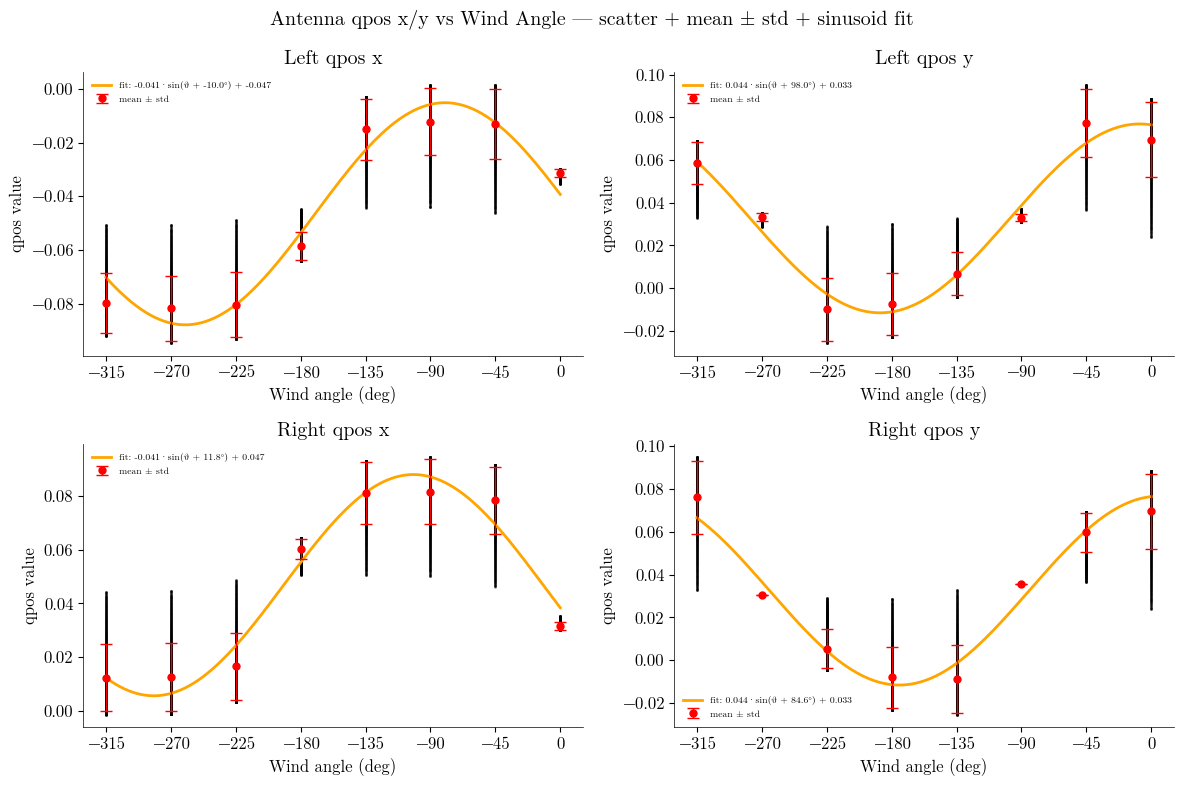

In [138]:
from scipy.optimize import curve_fit

sc = np.array(scatter_records)  # shape (N, 5): angle, l_x, l_y, r_x, r_y
angles_sc = sc[:, 0]

def sinusoid(theta_deg, A, phi, C):
    return A * np.sin(np.radians(theta_deg) + phi) + C

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=100)
specs = [
    (0, 0, "l_x", "Left qpos x"),
    (0, 1, "l_y", "Left qpos y"),
    (1, 0, "r_x", "Right qpos x"),
    (1, 1, "r_y", "Right qpos y"),
]
col_idx = {"l_x": 1, "l_y": 2, "r_x": 3, "r_y": 4}

for row, col, key, title in specs:
    ax = axes[row][col]
    vals = sc[:, col_idx[key]]
    ax.scatter(angles_sc, vals, s=1, alpha=0.15, rasterized=True)

    unique_angles = np.array(sorted(set(angles_sc)))
    means = np.array([vals[angles_sc == a].mean() for a in unique_angles])
    stds  = np.array([vals[angles_sc == a].std()  for a in unique_angles])
    ax.errorbar(unique_angles, means, yerr=stds, fmt='o', color='red',
                capsize=4, ms=5, label='mean ± std', zorder=3)

    # fit sinusoid to per-angle means
    p0 = [(means.max() - means.min()) / 2, 0.0, means.mean()]
    try:
        popt, _ = curve_fit(sinusoid, unique_angles, means, p0=p0)
        A, phi, C = popt
        theta_smooth = np.linspace(unique_angles.min(), unique_angles.max(), 300)
        ax.plot(theta_smooth, sinusoid(theta_smooth, *popt), color='orange', lw=2,
                label=f'fit: {A:.3f}·sin(θ + {np.degrees(phi):.1f}°) + {C:.3f}')
    except RuntimeError:
        ax.text(0.5, 0.5, 'fit failed', transform=ax.transAxes, ha='center', color='orange')

    ax.set_title(title)
    ax.set_xlabel("Wind angle (deg)")
    ax.set_ylabel("qpos value")
    ax.set_xticks(unique_angles)
    ax.legend(fontsize=7)
    

plt.suptitle("Antenna qpos x/y vs Wind Angle — scatter + mean ± std + sinusoid fit")
plt.tight_layout()
plt.show()

## Raw Signal Analysis
Characterise how the raw antenna `qpos` components vary with wind direction and magnitude — scatter plots, x/y ratio, and linear regression vs. magnitude — before fitting any model.

/var/folders/7z/392mmwys43l8y6c7ym46p13w0000gn/T/ipykernel_30903/4145317227.py:28: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(tangent, unique_angles, means, p0=p0,


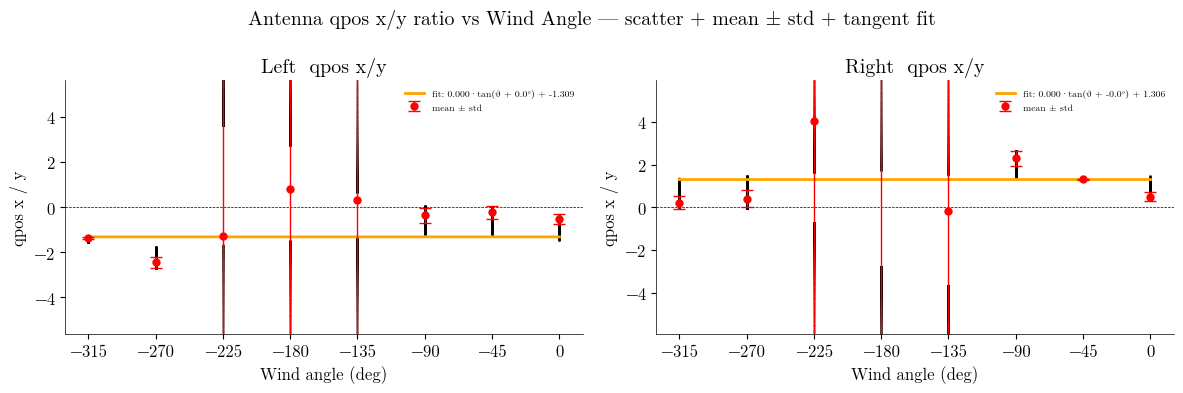

In [117]:
from scipy.optimize import curve_fit

sc = np.array(scatter_records)  # shape (N, 5): angle, l_x, l_y, r_x, r_y
angles_sc = sc[:, 0]

def tangent(theta_deg, A, phi, C):
    return A * np.tan(np.radians(theta_deg) + phi) + C

# compute x/y ratio per timestep (guard against near-zero y)
EPS = 1e-8
ratio_l = sc[:, 1] / np.where(np.abs(sc[:, 2]) < EPS, EPS, sc[:, 2])
ratio_r = sc[:, 3] / np.where(np.abs(sc[:, 4]) < EPS, EPS, sc[:, 4])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100)
for ax, ratio, title in zip(axes, [ratio_l, ratio_r], ["Left  qpos x/y", "Right  qpos x/y"]):
    CLIP = np.percentile(np.abs(ratio), 90)
    ax.scatter(angles_sc, ratio, s=1, alpha=0.15, rasterized=True)

    unique_angles = np.array(sorted(set(angles_sc)))
    means = np.array([ratio[angles_sc == a].mean() for a in unique_angles])
    stds  = np.array([ratio[angles_sc == a].std()  for a in unique_angles])
    ax.errorbar(unique_angles, means, yerr=stds, fmt='o', color='red',
                capsize=4, ms=5, label='mean ± std', zorder=3)

    # fit tangent — weight by 1/std so high-variance near-asymptote points don't dominate
    p0 = [1.0, 0.0, np.median(means)]
    try:
        popt, _ = curve_fit(tangent, unique_angles, means, p0=p0,
                            sigma=stds + 1e-6, absolute_sigma=False, maxfev=20000)
        A, phi, C = popt
        theta_smooth = np.linspace(unique_angles.min(), unique_angles.max(), 3000)
        y_fit = tangent(theta_smooth, *popt)
        y_fit[np.abs(y_fit) > 4 * CLIP] = np.nan  # hide asymptotic blowup
        ax.plot(theta_smooth, y_fit, color='orange', lw=2,
                label=f'fit: {A:.3f}·tan(θ + {np.degrees(phi):.1f}°) + {C:.3f}')
    except RuntimeError:
        ax.text(0.5, 0.5, 'fit failed', transform=ax.transAxes, ha='center', color='orange')

    ax.set_title(title)
    ax.set_xlabel("Wind angle (deg)")
    ax.set_ylabel("qpos x / y")
    ax.set_xticks(unique_angles)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set_ylim(-CLIP, CLIP)
    ax.legend(fontsize=7)

plt.suptitle("Antenna qpos x/y ratio vs Wind Angle — scatter + mean ± std + tangent fit")
plt.tight_layout()
plt.show()

/var/folders/7z/392mmwys43l8y6c7ym46p13w0000gn/T/ipykernel_30903/3816382850.py:30: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  slope, intercept, r, *_ = linregress(mags, vals)


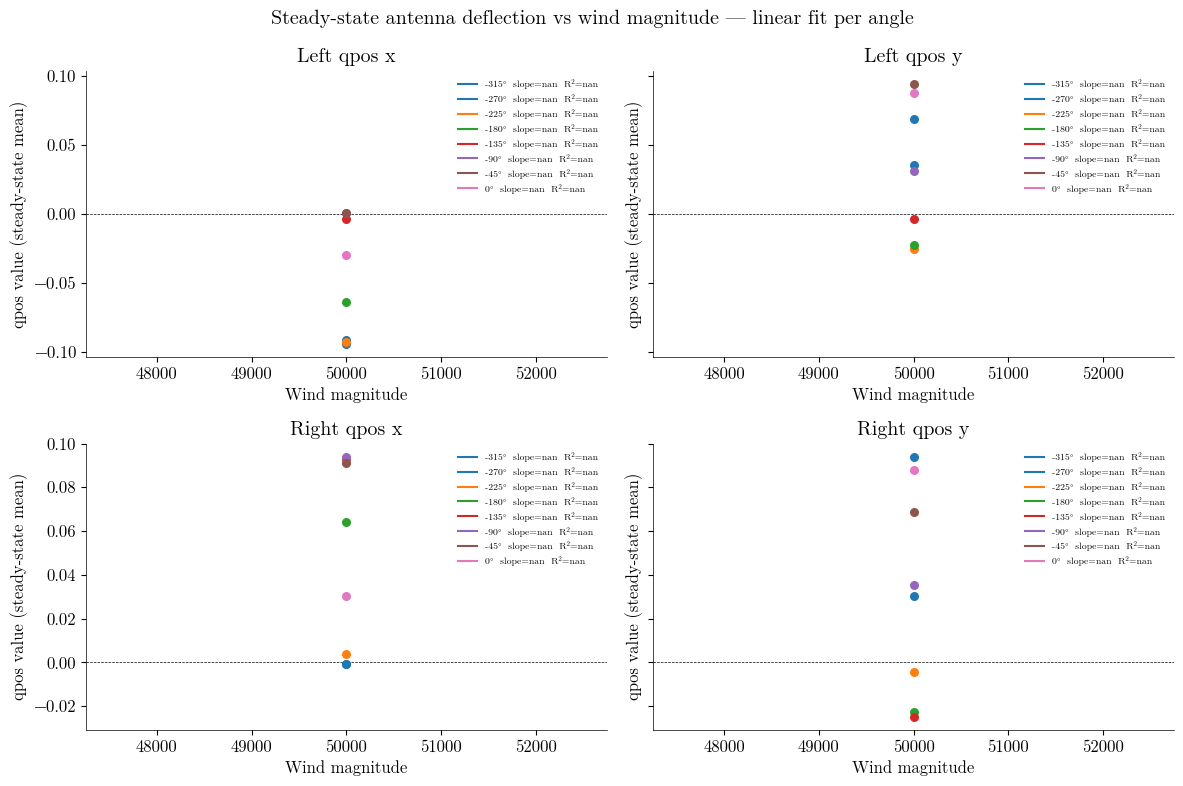

In [118]:
from scipy.stats import linregress

# Use last 200 steps per (angle, magnitude) block as "steady state"
steady = df[df["step"] >= 1800].groupby(["angle", "magnitude"])[
    ["l_qx", "l_qy", "r_qx", "r_qy"]
].mean().reset_index()

angles_u = sorted(steady["angle"].unique())
mags_u   = sorted(steady["magnitude"].unique())
colors   = plt.cm.tab10(np.linspace(0, 0.6, len(angles_u)))

specs = [
    ("l_qx", "Left qpos x"),
    ("l_qy", "Left qpos y"),
    ("r_qx", "Right qpos x"),
    ("r_qy", "Right qpos y"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=100, sharey='row')

for ax, (key, title) in zip(axes.flat, specs):
    for angle, color in zip(angles_u, colors):
        g = steady[steady["angle"] == angle].sort_values("magnitude")
        mags = g["magnitude"].values.astype(float)
        vals = g[key].values

        ax.scatter(mags, vals, color=color, s=30, zorder=3)

        # linear fit
        slope, intercept, r, *_ = linregress(mags, vals)
        m_smooth = np.linspace(mags.min(), mags.max(), 200)
        ax.plot(m_smooth, slope * m_smooth + intercept, color=color, lw=1.5,
                
                label=f"{angle}°  slope={slope:.2e}  R²={r**2:.3f}")

    ax.set_title(title)
    ax.set_xlabel("Wind magnitude")
    ax.set_ylabel("qpos value (steady-state mean)")
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.legend(fontsize=7)

plt.suptitle("Steady-state antenna deflection vs wind magnitude — linear fit per angle")
plt.tight_layout()
plt.show()

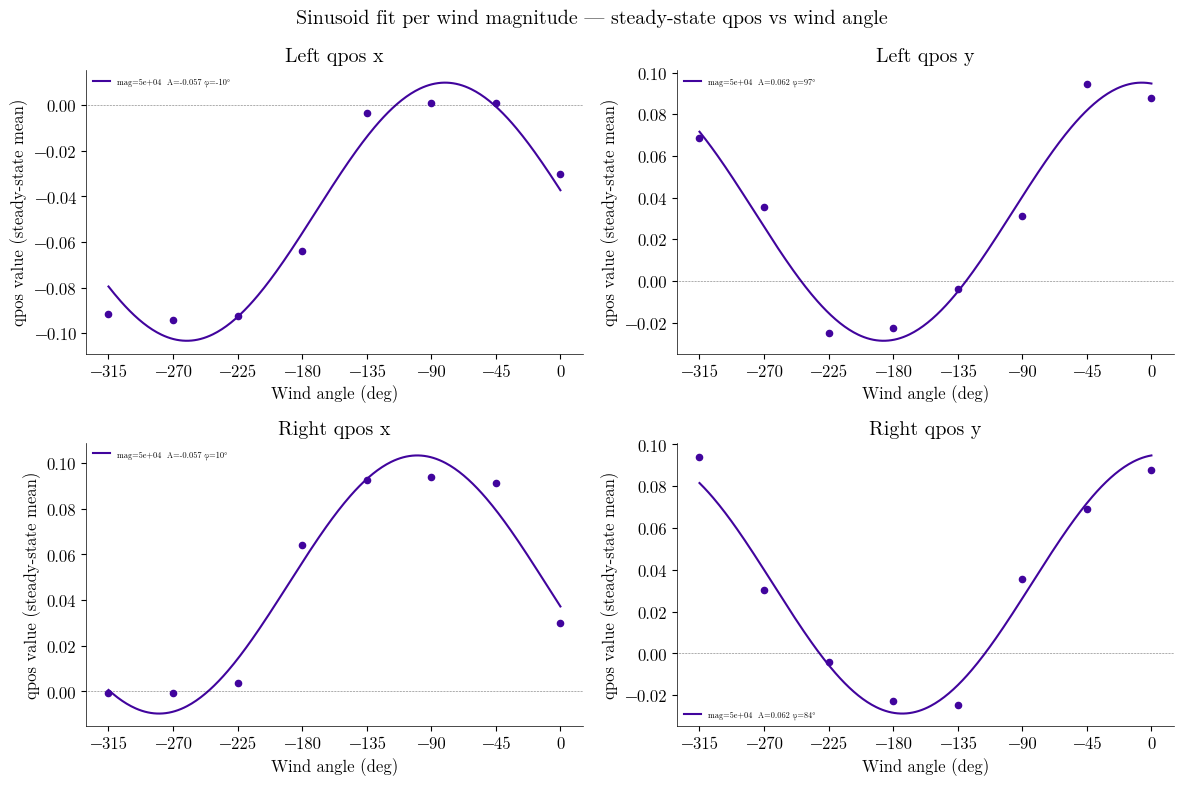

In [119]:
from scipy.optimize import curve_fit

def sinusoid(theta_deg, A, phi, C):
    return A * np.sin(np.radians(theta_deg) + phi) + C

steady = df[df["step"] >= 1800].groupby(["angle", "magnitude"])[
    ["l_qx", "l_qy", "r_qx", "r_qy"]
].mean().reset_index()

mags   = sorted(steady["magnitude"].unique())
specs  = [("l_qx", "Left qpos x"), ("l_qy", "Left qpos y"),
          ("r_qx", "Right qpos x"), ("r_qy", "Right qpos y")]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, max(len(mags), 2)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8), dpi=100)
for ax, (key, title) in zip(axes.flat, specs):
    for mag, color in zip(mags, colors):
        g = steady[steady["magnitude"] == mag].sort_values("angle")
        angles_m = g["angle"].values.astype(float)
        means_m  = g[key].values

        ax.scatter(angles_m, means_m, color=color, s=20, zorder=3)

        p0 = [(means_m.max() - means_m.min()) / 2, 0.0, means_m.mean()]
        try:
            popt, _ = curve_fit(sinusoid, angles_m, means_m, p0=p0)
            A, phi, C = popt
            theta_smooth = np.linspace(angles_m.min(), angles_m.max(), 300)
            ax.plot(theta_smooth, sinusoid(theta_smooth, *popt), color=color, lw=1.5,
                    label=f"mag={mag:.0e}  A={A:.3f} φ={np.degrees(phi):.0f}°")
        except RuntimeError:
            ax.plot([], [], color=color, label=f"mag={mag:.0e}  fit failed")

    ax.set_title(title)
    ax.set_xlabel("Wind angle (deg)")
    ax.set_ylabel("qpos value (steady-state mean)")
    ax.set_xticks(sorted(steady["angle"].unique()))
    ax.axhline(0, color='k', lw=0.4, ls=':')
    ax.legend(fontsize=6)

plt.suptitle("Sinusoid fit per wind magnitude — steady-state qpos vs wind angle")
plt.tight_layout()
plt.show()

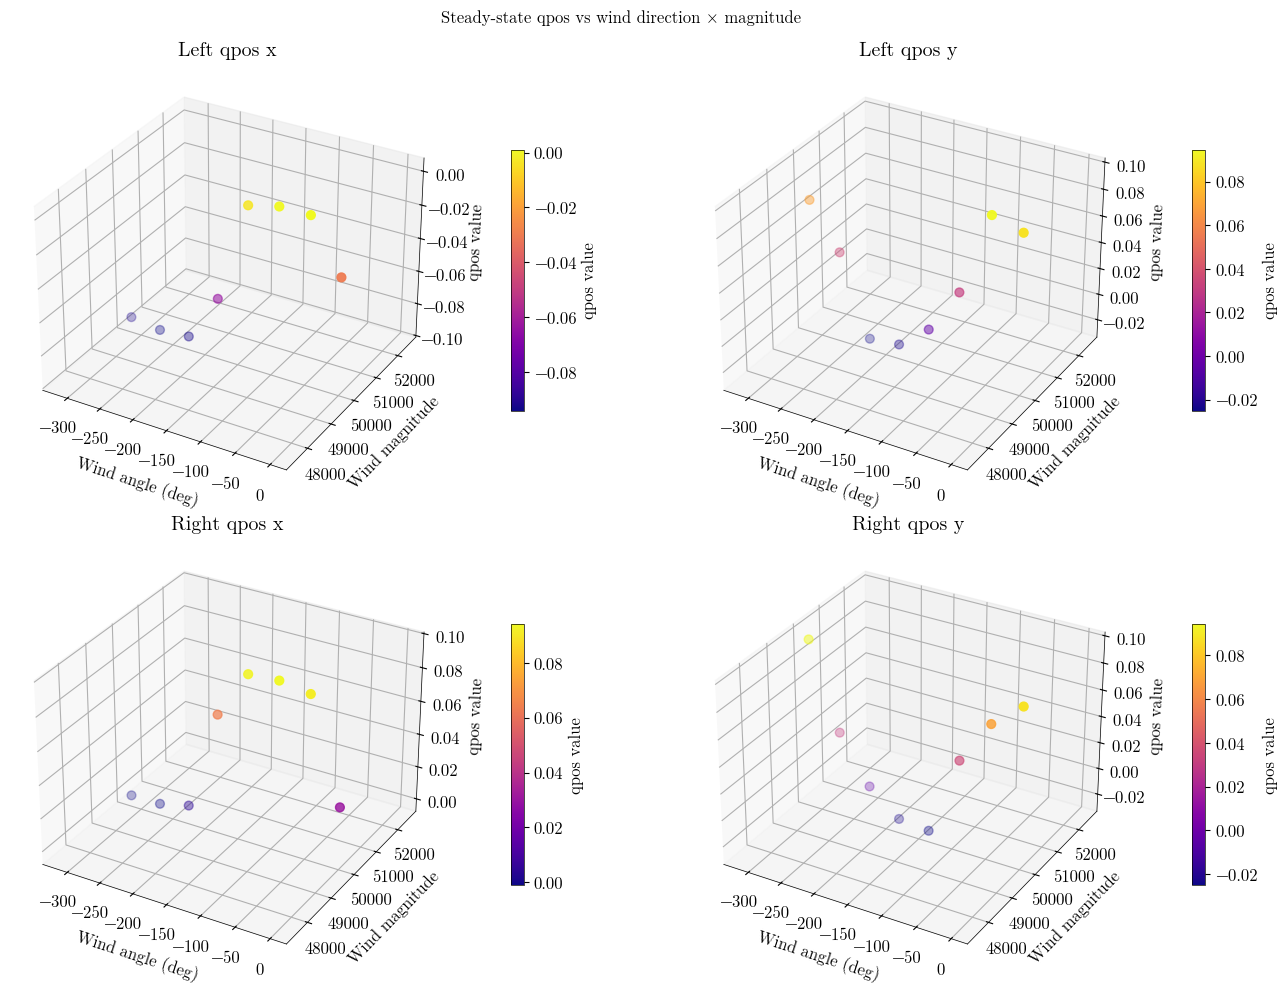

In [120]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# steady-state mean per (angle, magnitude)
steady3d = df[df["step"] >= 1800].groupby(["angle", "magnitude"])[
    ["l_qx", "l_qy", "r_qx", "r_qy"]
].mean().reset_index()

angles_3d = steady3d["angle"].values.astype(float)
mags_3d   = steady3d["magnitude"].values.astype(float)

specs = [
    ("l_qx", "Left qpos x"),
    ("l_qy", "Left qpos y"),
    ("r_qx", "Right qpos x"),
    ("r_qy", "Right qpos y"),
]

fig = plt.figure(figsize=(14, 10), dpi=100)
for idx, (key, title) in enumerate(specs, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    vals = steady3d[key].values

    sc = ax.scatter(angles_3d, mags_3d, vals,
                    c=vals, cmap='plasma', s=40, depthshade=True)
    fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6, label="qpos value")

    ax.set_xlabel("Wind angle (deg)", labelpad=6)
    ax.set_ylabel("Wind magnitude", labelpad=6)
    ax.set_zlabel("qpos value", labelpad=4)
    ax.set_title(title)

plt.suptitle("Steady-state qpos vs wind direction × magnitude", fontsize=12)
plt.tight_layout()
plt.show()

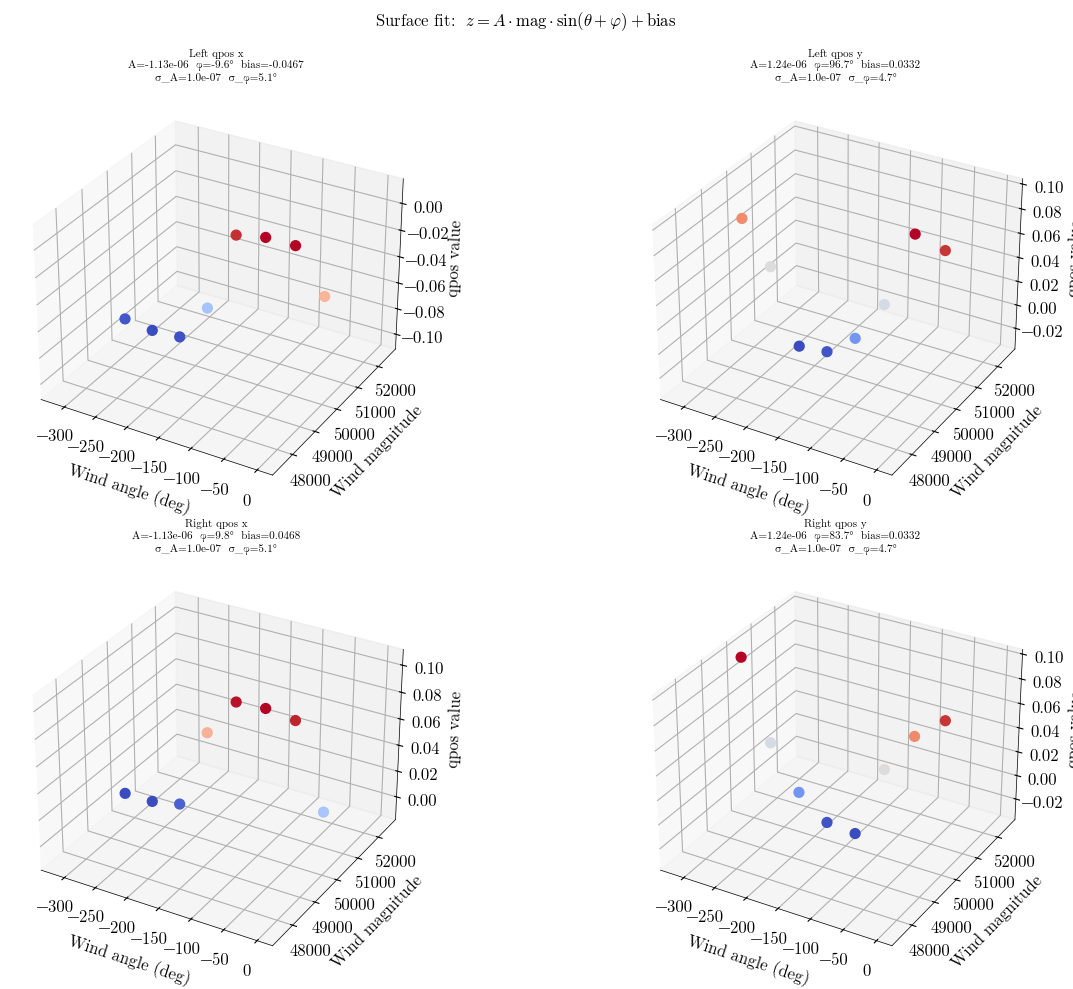


component             A          σ_A      φ (°)    σ_φ (°)         bias       σ_bias
--------------------------------------------------------------------------------
l_qx        -1.1320e-06   1.0100e-07      -9.58       5.11  -4.6726e-02   3.5708e-03
l_qy         1.2395e-06   1.0122e-07      96.70       4.68   3.3241e-02   3.5786e-03
r_qx        -1.1308e-06   1.0032e-07       9.79       5.08   4.6823e-02   3.5467e-03
r_qy         1.2389e-06   1.0142e-07      83.67       4.69   3.3170e-02   3.5858e-03

Saved → /Users/martavasconcelos/Documents/EPFL/study/BE-456/project/cobar-miniproject-2026/miniproject/notebooks/wind_fit_params.csv


In [121]:
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
import pathlib

def surface_model(X, A, phi, bias):
    """z = A * magnitude * sin(angle_rad + phi) + bias"""
    angle_rad = np.radians(X[0])
    magnitude = X[1]
    return A * magnitude * np.sin(angle_rad + phi) + bias

steady3d = df[df["step"] >= 1800].groupby(["angle", "magnitude"])[
    ["l_qx", "l_qy", "r_qx", "r_qy"]
].mean().reset_index()

angles_fit = steady3d["angle"].values.astype(float)
mags_fit   = steady3d["magnitude"].values.astype(float)
X_fit      = np.vstack([angles_fit, mags_fit])

specs = [("l_qx", "Left qpos x"), ("l_qy", "Left qpos y"),
         ("r_qx", "Right qpos x"), ("r_qy", "Right qpos y")]

fit_results = {}

fig = plt.figure(figsize=(14, 10), dpi=100)
for idx, (key, title) in enumerate(specs, 1):
    ax = fig.add_subplot(2, 2, idx, projection='3d')
    z  = steady3d[key].values

    try:
        popt, pcov = curve_fit(surface_model, X_fit, z, p0=[1e-6, 0.0, 0.0], maxfev=20000)
        A, phi, bias = popt
        perr = np.sqrt(np.diag(pcov))
        fit_results[key] = dict(A=A, phi_deg=np.degrees(phi), bias=bias,
                                sigma_A=perr[0], sigma_phi_deg=np.degrees(perr[1]), sigma_bias=perr[2])
        fit_ok = True
    except RuntimeError:
        fit_results[key] = None
        fit_ok = False

    ax.scatter(angles_fit, mags_fit, z, c=z, cmap='coolwarm', s=50, zorder=5, depthshade=False)

    if fit_ok:
        ag = np.linspace(angles_fit.min(), angles_fit.max(), 60)
        mg = np.linspace(mags_fit.min(),   mags_fit.max(),   60)
        AG, MG = np.meshgrid(ag, mg)
        ZG = surface_model(np.vstack([AG.ravel(), MG.ravel()]), *popt).reshape(AG.shape)
        ax.plot_surface(AG, MG, ZG, alpha=0.3, cmap='coolwarm', linewidth=0)
        label = (f"A={A:.2e}  φ={np.degrees(phi):.1f}°  bias={bias:.4f}\n"
                 f"σ_A={perr[0]:.1e}  σ_φ={np.degrees(perr[1]):.1f}°")
        ax.set_title(f"{title}\n{label}", fontsize=8)
    else:
        ax.set_title(f"{title}\nfit failed", fontsize=8)

    ax.set_xlabel("Wind angle (deg)", labelpad=6)
    ax.set_ylabel("Wind magnitude",   labelpad=6)
    ax.set_zlabel("qpos value",       labelpad=4)

plt.suptitle(r"Surface fit:  $z = A \cdot \mathrm{mag} \cdot \sin(\theta + \varphi) + \mathrm{bias}$",
             fontsize=12)
plt.tight_layout()
plt.show()

# ── print parameter table ─────────────────────────────────────────────
print(f"\n{'component':<10} {'A':>12} {'σ_A':>12} {'φ (°)':>10} {'σ_φ (°)':>10} {'bias':>12} {'σ_bias':>12}")
print("-" * 80)
for key, title in specs:
    r = fit_results[key]
    if r is None:
        print(f"{key:<10}  fit failed")
    else:
        print(f"{key:<10} {r['A']:>12.4e} {r['sigma_A']:>12.4e} "
              f"{r['phi_deg']:>10.2f} {r['sigma_phi_deg']:>10.2f} "
              f"{r['bias']:>12.4e} {r['sigma_bias']:>12.4e}")

# ── export CSV (A, phi_deg, bias only — no std) ───────────────────────
rows = [{"component": k, "A": r["A"], "phi_deg": r["phi_deg"], "bias": r["bias"]}
        for k, r in fit_results.items() if r is not None]
csv_path = pathlib.Path(__file__).parent / "wind_fit_params.csv" \
    if "__file__" in dir() else pathlib.Path("wind_fit_params.csv")
pd.DataFrame(rows).to_csv(csv_path, index=False)
print(f"\nSaved → {csv_path.resolve()}")

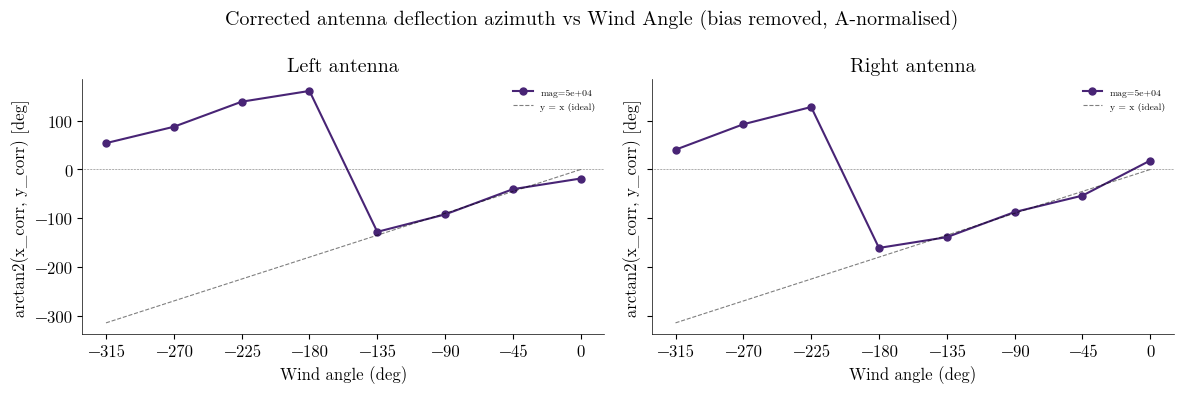

In [122]:
# Rescale and debias each component using fit_results before computing arctan2:
#   x_corr = (qpos_x - bias_x) / A_x  →  magnitude · sin(angle + φ_x)
#   y_corr = (qpos_y - bias_y) / A_y  →  magnitude · sin(angle + φ_y)
# The magnitude factor cancels in arctan2, leaving a cleaner angle estimate.

steady = df[df["step"] >= 1800].copy()

for side, xk, yk in [("l", "l_qx", "l_qy"), ("r", "r_qx", "r_qy")]:
    x_corr = (steady[xk] - fit_results[xk]["bias"]) / fit_results[xk]["A"]
    y_corr = (steady[yk] - fit_results[yk]["bias"]) / fit_results[yk]["A"]
    steady[f"{side}_atan"] = np.degrees(np.arctan2(x_corr, y_corr))

# mean per (angle, magnitude)
grouped = steady.groupby(["angle", "magnitude"])[["l_atan", "r_atan"]].mean().reset_index()

mags     = sorted(grouped["magnitude"].unique())
angles_u = sorted(grouped["angle"].unique())
colors   = plt.cm.viridis(np.linspace(0.1, 0.9, max(len(mags), 2)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=100, sharey=True)
for ax, key, title in zip(axes, ["l_atan", "r_atan"], ["Left antenna", "Right antenna"]):
    for mag, color in zip(mags, colors):
        g = grouped[grouped["magnitude"] == mag].sort_values("angle")
        ax.plot(g["angle"], g[key], 'o-', color=color, lw=1.5, ms=5, label=f"mag={mag:.0e}")

    ax.plot(angles_u, angles_u, 'k--', lw=0.8, alpha=0.5, label="y = x (ideal)")
    ax.set_title(title)
    ax.set_xlabel("Wind angle (deg)")
    ax.set_ylabel("arctan2(x_corr, y_corr) [deg]")
    ax.set_xticks(angles_u)
    ax.axhline(0, color='k', lw=0.4, ls=':')
    ax.legend(fontsize=7)

plt.suptitle("Corrected antenna deflection azimuth vs Wind Angle (bias removed, A-normalised)")
plt.tight_layout()
plt.show()

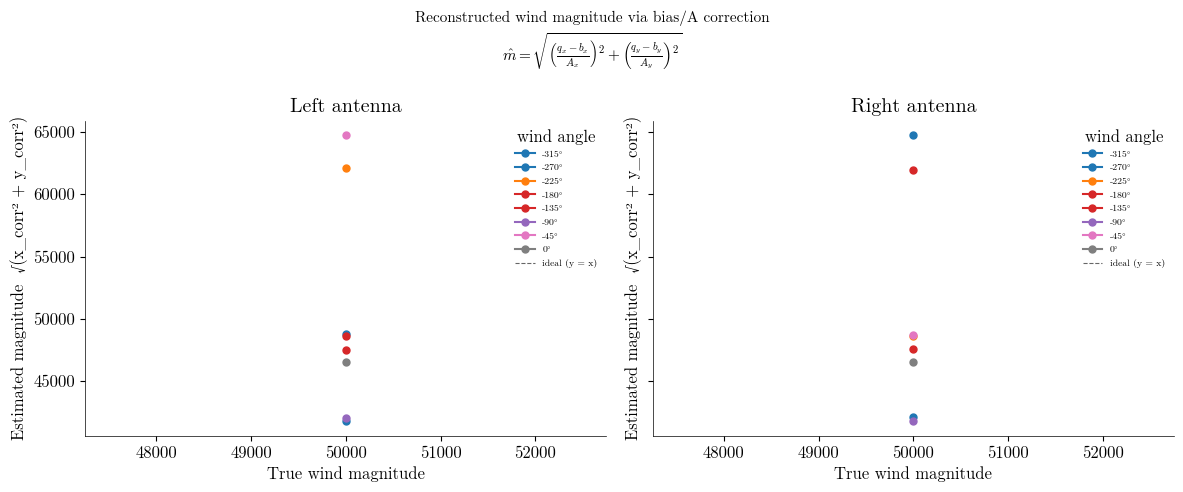

In [123]:
# Corrected magnitude estimate:
#   corrected = (qpos - bias) / A  →  magnitude · sin(angle + φ)
#   √(x_corr² + y_corr²) = magnitude · √(sin²(angle+φ_x) + sin²(angle+φ_y))
#                         = magnitude  exactly when φ_x and φ_y are 90° apart

steady_mag = df[df["step"] >= 1800].groupby(["angle", "magnitude"])[
    ["l_qx", "l_qy", "r_qx", "r_qy"]
].mean().reset_index()

angles_u = sorted(steady_mag["angle"].unique())
colors   = plt.cm.tab10(np.linspace(0, 0.7, len(angles_u)))

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100, sharey=True)
for ax, (xk, yk), title in zip(
    axes,
    [("l_qx", "l_qy"), ("r_qx", "r_qy")],
    ["Left antenna", "Right antenna"],
):
    p_x = fit_results[xk]
    p_y = fit_results[yk]

    x_corr = (steady_mag[xk] - p_x["bias"]) / p_x["A"]
    y_corr = (steady_mag[yk] - p_y["bias"]) / p_y["A"]
    steady_mag[f"mag_est_{xk[0]}"] = np.sqrt(x_corr**2 + y_corr**2)

    actual_mags = sorted(steady_mag["magnitude"].unique())
    for angle, color in zip(angles_u, colors):
        g = steady_mag[steady_mag["angle"] == angle].sort_values("magnitude")
        ax.plot(g["magnitude"], g[f"mag_est_{xk[0]}"], 'o-',
                color=color, lw=1.5, ms=5, label=f"{angle}°")

    # ideal y = x reference
    ax.plot(actual_mags, actual_mags, 'k--', lw=0.8, alpha=0.6, label="ideal (y = x)")

    ax.set_title(title)
    ax.set_xlabel("True wind magnitude")
    ax.set_ylabel("Estimated magnitude  √(x_corr² + y_corr²)")
    ax.legend(fontsize=7, title="wind angle")

plt.suptitle(
    "Reconstructed wind magnitude via bias/A correction\n"
    r"$\hat{m} = \sqrt{\left(\frac{q_x - b_x}{A_x}\right)^2 + \left(\frac{q_y - b_y}{A_y}\right)^2}$",
    fontsize=11,
)
plt.tight_layout()
plt.show()

We can retrieve the joint state (position in quaternion format, angular velocities and accelerations) and torques with `sim.get_antenna_data`:

In [124]:
sim.get_antenna_data(fly.name)

{'l': {'qpos': array([ 0.99810989, -0.05029496,  0.03528567, -0.00141023]),
  'qvel': array([ 0.07704319, -0.06789181,  0.03008794]),
  'qacc': array([-2.22625649,  2.45708309, -1.268918  ]),
  'qfrc_passive': array([ 9.29461070e-04, -6.38242840e-04, -1.86411956e-06])},
 'r': {'qpos': array([0.99833506, 0.04415471, 0.0370607 , 0.00199555]),
  'qvel': array([ 0.09024625, -0.11491048, -0.02641179]),
  'qacc': array([-3.2693506 ,  4.56071167,  2.13516148]),
  'qfrc_passive': array([-9.73861688e-04, -6.26675886e-04, -1.35435493e-05])}}

## Explorations into the kinematic chain of the fly model

In [125]:
qpos = sim.get_antenna_data(fly.name)['l']['qpos']

In [126]:
side = 'r'
model = sim.mj_model.joint(f"{fly.name}/{side}_funiculus_ball_joint")
q_rest = model.qpos0

In [ ]:
from scipy.spatial.transform import Rotation as R

def quat_mjc_to_scipy(q_mjc):
    # Convert from (w, x, y, z) to (x, y, z, w)
    return np.array([q_mjc[1], q_mjc[2], q_mjc[3], q_mjc[0]])

def quat_multiply(q1, q2):
    r1 = R.from_quat(q1)
    r2 = R.from_quat(q2)
    r_result = r1 * r2
    return r_result.as_quat()

def quat_inv(q):
    r = R.from_quat(q)
    r_inv = r.inv()
    return r_inv.as_quat()

q_delta = quat_multiply(quat_inv(quat_mjc_to_scipy(q_rest)), quat_mjc_to_scipy(qpos))
print(qpos, q_delta, q_rest)

[ 9.98278719e-01 -4.81884020e-02  3.34258130e-02 -4.39455046e-04] [-4.81884020e-02  3.34258130e-02 -4.39455046e-04  9.98278719e-01] [1. 0. 0. 0.]


In [ ]:
model

<_MjModelJointViews
  M0: array([7.77605850e-08, 5.82769258e-08, 2.70797033e-08])
  Madr: array([45, 52, 60], dtype=int32)
  armature: array([0., 0., 0.])
  axis: array([0., 0., 1.])
  bodyid: array([16, 16, 16], dtype=int32)
  damping: array([0.001, 0.001, 0.001])
  dofadr: array([9], dtype=int32)
  frictionloss: array([0., 0., 0.])
  group: array([0], dtype=int32)
  id: 2
  invweight0: array([24222758.94749223, 24222758.94749223, 24222758.94749223])
  jntid: array([2, 2, 2], dtype=int32)
  limited: array([0], dtype=uint8)
  margin: array([0.])
  name: 'nmf/r_funiculus_ball_joint'
  parentid: array([ 5,  9, 10], dtype=int32)
  pos: array([0., 0., 0.])
  qpos0: array([1., 0., 0., 0.])
  qpos_spring: array([1., 0., 0., 0.])
  qposadr: array([11], dtype=int32)
  range: array([0., 0.])
  simplenum: array([0, 0, 0], dtype=int32)
  solimp: array([9.0e-01, 9.5e-01, 1.0e-03, 5.0e-01, 2.0e+00])
  solref: array([0.02, 1.  ])
  stiffness: array([0.01])
  type: array([1], dtype=int32)
  user: arr

In [ ]:
import mujoco as mujoco
# This is the right one — the body the joint is attached to
parent_body_id = sim.mj_model.body_parentid[16]
parent_name = mujoco.mj_id2name(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, parent_body_id)
print(parent_name)

nmf/r_pedicel


In [ ]:
sim.get_antenna_data(fly.name)

{'l': {'qpos': array([ 9.98278719e-01, -4.81884020e-02,  3.34258130e-02, -4.39455046e-04]),
  'qvel': array([ 0.01904624, -0.01813764,  0.01127342]),
  'qacc': array([-0.52897572,  0.66803556, -0.51221523]),
  'qfrc_passive': array([ 9.45267872e-04, -6.50756247e-04, -2.47882863e-06])},
 'r': {'qpos': array([9.98336970e-01, 4.66174204e-02, 3.39043647e-02, 7.78010565e-04]),
  'qvel': array([ 0.02396599, -0.03074457, -0.01403   ]),
  'qacc': array([-0.90353978,  1.23775589,  0.92484507]),
  'qfrc_passive': array([-9.56839647e-04, -6.47708630e-04, -1.54462747e-06])}}

`qpos`is given as a rotation wrt `qpos0`, which itself is referenced to the parent body of the antenna. What is the parent body of the antenna?

In [ ]:
import mujoco

# get the body id of the funiculus (or whatever the antenna body is called)
body_id = mujoco.mj_name2id(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, f"{fly.name}/{side}_funiculus")
print('body id:', body_id)

# then walk up the parent chain
body = body_id
while body != 0:  # 0 is the world body
    name = mujoco.mj_id2name(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, body)
    parent = sim.mj_model.body_parentid[body]
    print(f"{body}: {name} → parent: {parent}")
    body = parent

body id: 16
16: nmf/r_funiculus → parent: 15
15: nmf/r_pedicel → parent: 2
2: nmf/c_thorax → parent: 1
1: nmf/ → parent: 0


The parent body of the antenna — the joint's name is actually `side_funiculus_ball_joint`, belonging to the `side_funiculus` body — is the pedicel, meaning that, to calculate the direction of the antennas' deflection wrt the fly's body, we need to understand how to transform this vector into the fly's reference frame.

To do this, the trick is to apply the qpos rotation to the vector that represents the position of the ball joint at rest, and then converting this into the fly's frame of reference by rising up the kinematic chain up to the thorax.

In [ ]:
# check if the pedicel has any joints
for i in range(sim.mj_model.njnt):
    body = sim.mj_model.jnt_bodyid[i]
    name = mujoco.mj_id2name(sim.mj_model, mujoco.mjtObj.mjOBJ_BODY, body)
    if "pedicel" in name:
        print(name, mujoco.mj_id2name(sim.mj_model, mujoco.mjtObj.mjOBJ_JOINT, i))

Pedicel has no joints, so the position of the ball joint wrt the thorax should be fixed — we can cache the rest vector of the antennae wrt the thorax instead of calculating it every time.

---
## Debugging: Hypothesis 1 — Transient Antenna Dynamics

The fit parameters were derived from the **last 200 steps (steady state) of a 2000-step** wind application. In the actual controller, the fly continuously changes heading so the antennae may never fully settle. The cells below check whether the `arctan2` pipeline works in the transient regime.

In [134]:
def wrap_angle(a):
    """Cast angle(s) in degrees to the arctan2 output interval (-180, 180]."""
    return ((np.asarray(a, dtype=float) + 180) % 360) - 180

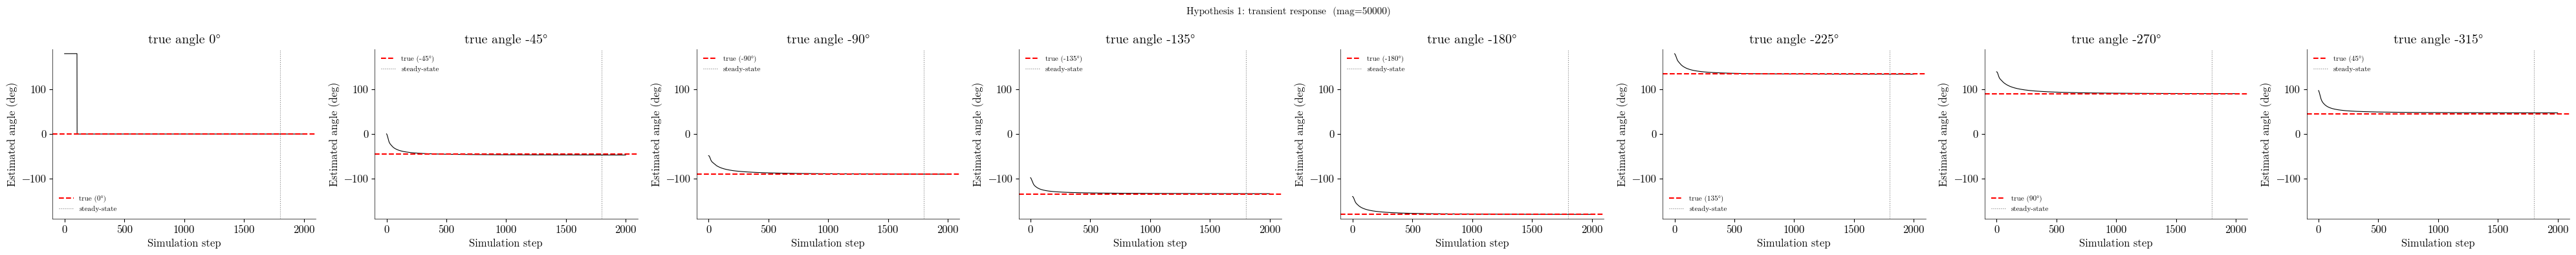

In [135]:
# Step 1: Transient response — full time series of corrected signals and estimated angle
WIND_MAG    = 50000
TEST_ANGLES = [0, -45, -90, -135, -180, -225, -270, -315]

# Apply bias/amplitude correction to the full df (all timesteps)
for key, p in [("l_qx", fit_results["l_qx"]),
               ("l_qy", fit_results["l_qy"]),
               ("r_qx", fit_results["r_qx"]),
               ("r_qy", fit_results["r_qy"])]:
    df[f"{key}_corr"] = (df[key] - p["bias"]) / p["A"]

# Circular mean: convert to unit vectors, sum, then recover angle
l_rad = np.arctan2(df["l_qx_corr"], df["l_qy_corr"])
r_rad = np.arctan2(df["r_qx_corr"], df["r_qy_corr"])
df["angle_est"] = np.degrees(np.angle(np.exp(1j * l_rad) + np.exp(1j * r_rad)))

fig, axes = plt.subplots(1, len(TEST_ANGLES), figsize=(40, 4), dpi=100, sharex=True)

for col_i, true_angle in enumerate(TEST_ANGLES):
    g = df[(df["angle"] == true_angle) & (df["magnitude"] == WIND_MAG)].sort_values("step")
    ax = axes[col_i]
    ax.plot(g["step"], g["angle_est"], lw=0.8)
    ax.axhline(wrap_angle(true_angle), color="r", lw=1.5, ls="--",
               label=f"true ({wrap_angle(true_angle):.0f}°)")
    ax.axvline(1800, color="k", lw=0.8, ls=":", alpha=0.5, label="steady-state")
    ax.set_title(f"true angle {true_angle}°")
    ax.set_xlabel("Simulation step")
    ax.set_ylabel("Estimated angle (deg)")
    ax.set_ylim(-190, 190)
    ax.legend(fontsize=8)

plt.suptitle(f"Hypothesis 1: transient response  (mag={WIND_MAG})", fontsize=11)
plt.tight_layout()
plt.show()

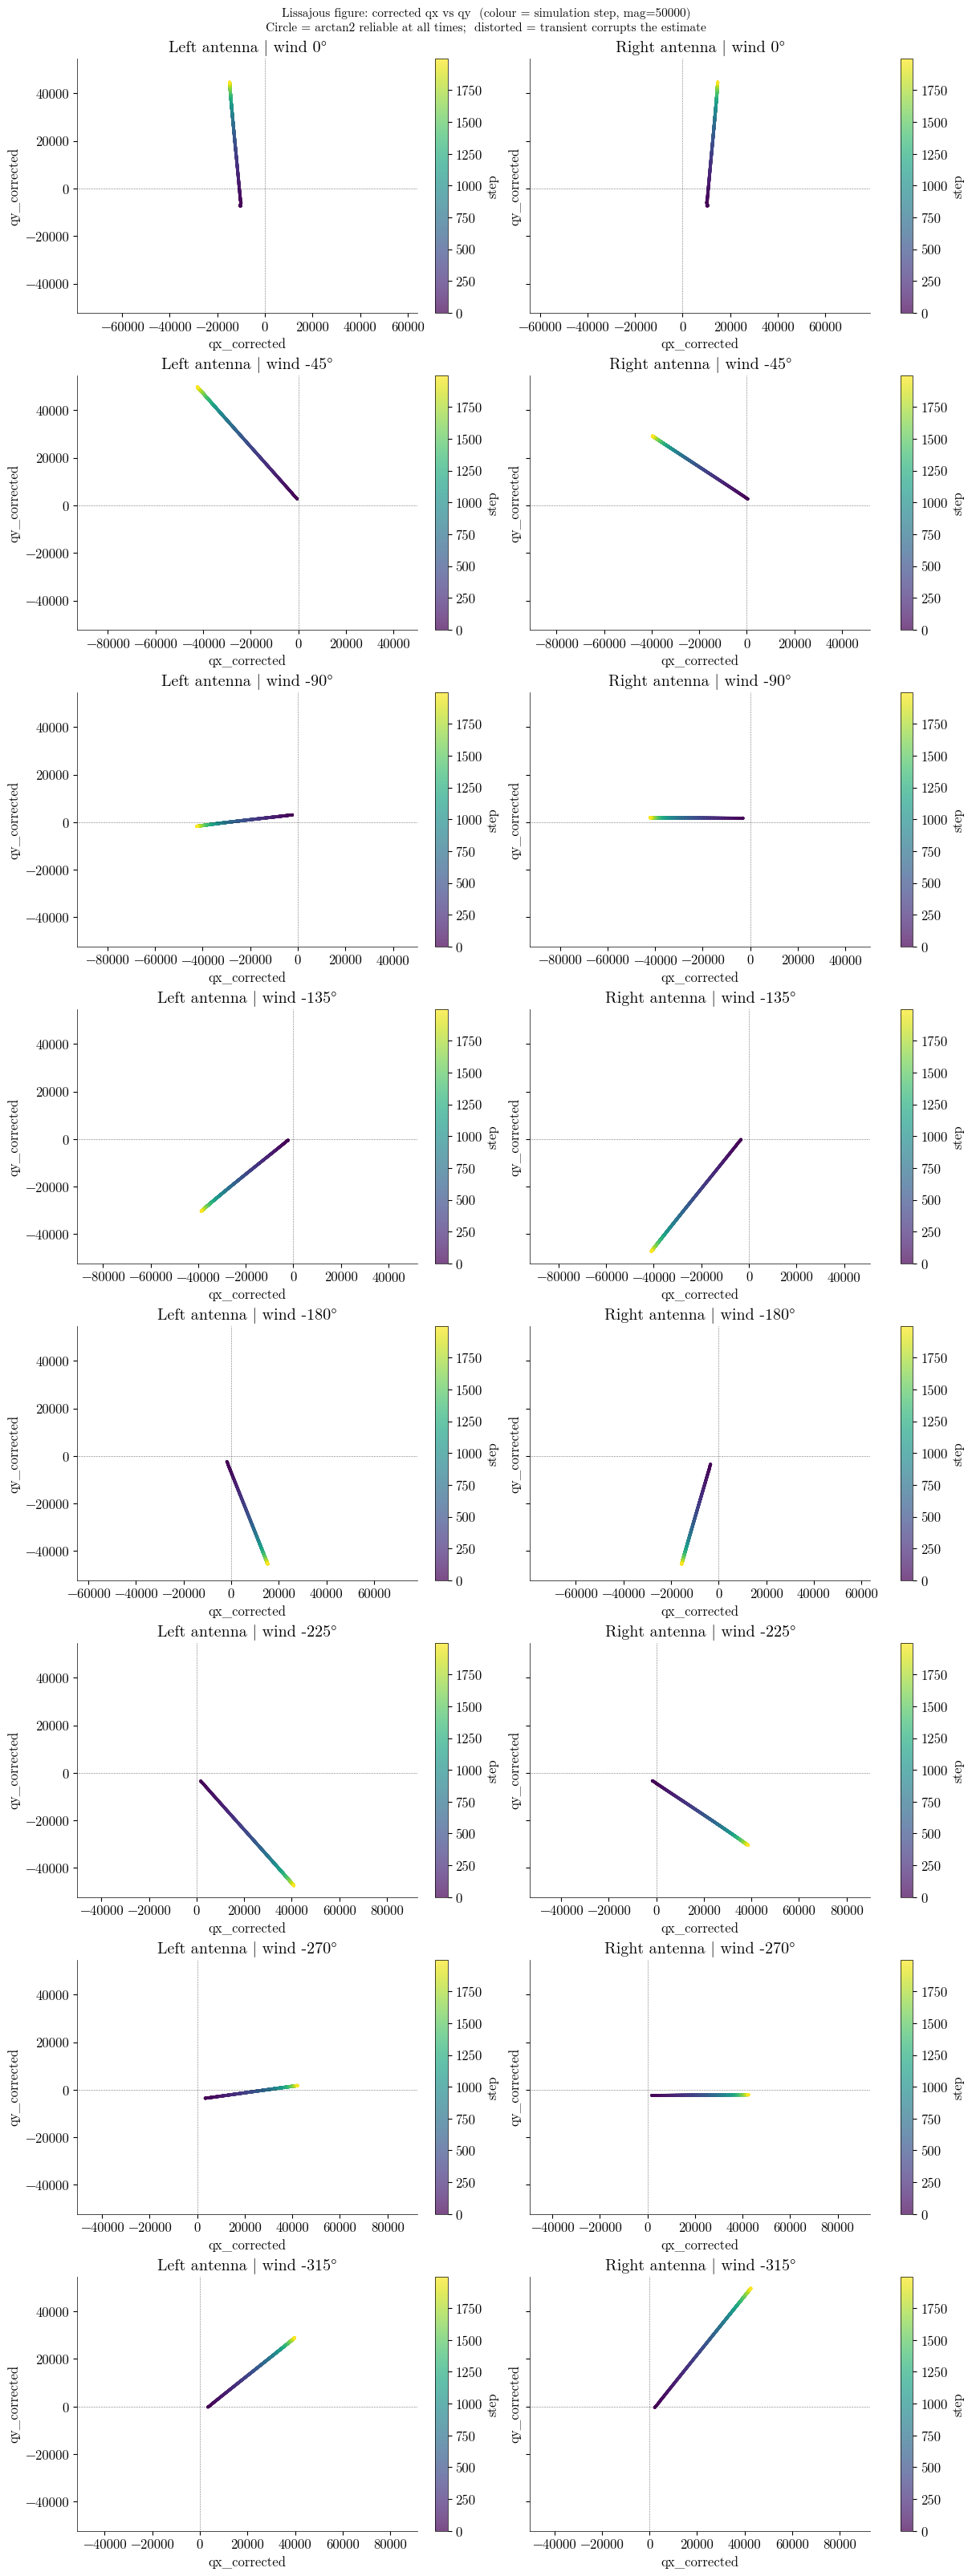

In [136]:
# Step 2: Lissajous figure — qy_corrected vs qx_corrected over time  (mag=50000)
# A circular trace means the phase difference is ~90° at all timesteps → arctan2 is reliable.
# A distorted / elongated trace means the transient breaks the estimate.

WIND_MAG         = 50000
LISSAJOUS_ANGLES = [0, -45, -90, -135, -180, -225, -270, -315]  # angles as stored in df (b64c6f0d uses -45*i)

fig, axes = plt.subplots(len(LISSAJOUS_ANGLES), 2,
                         figsize=(12, 4 * len(LISSAJOUS_ANGLES)), dpi=100,  sharey=True, layout="constrained")

for row_i, true_angle in enumerate(LISSAJOUS_ANGLES):
    g = df[(df["angle"] == true_angle) & (df["magnitude"] == WIND_MAG)].sort_values("step")

    for col_i, (xk, yk, title) in enumerate([
        ("l_qx_corr", "l_qy_corr", "Left antenna"),
        ("r_qx_corr", "r_qy_corr", "Right antenna"),
    ]):
        ax = axes[row_i][col_i]
        sc = ax.scatter(g[xk], g[yk], c=g["step"], cmap="viridis", s=3, alpha=0.7, rasterized=True)
        plt.colorbar(sc, ax=ax, label="step", fraction=0.046, pad=0.04)
        ax.axhline(0, color="k", lw=0.4, ls=":")
        ax.axvline(0, color="k", lw=0.4, ls=":")
        ax.set_xlabel("qx_corrected")
        ax.set_ylabel("qy_corrected")
        ax.set_aspect("equal", "datalim")
        ax.set_title(f"{title} | wind {true_angle}°")

plt.suptitle(
    f"Lissajous figure: corrected qx vs qy  (colour = simulation step, mag={WIND_MAG})\n"
    "Circle = arctan2 reliable at all times;  distorted = transient corrupts the estimate",
    fontsize=11,
)
#plt.tight_layout()
plt.show()

---
## Wind-Jump Time Series: True vs Estimated Angle

To understand how the antenna transient affects estimation, we simulate the same
random wind-direction jumps that occur in the full simulation and plot the
**true** egocentric wind angle against the **estimated** angle from the raw
arctan2 pipeline (no transient correction).

Vertical dashed lines mark each jump onset.  The settling artefacts (especially
the 180° spike at 0° headwind) should be clearly visible.

In [145]:
# ── Random wind-jump time series ──────────────────────────────────────────────
# Records step-by-step estimated wind angle (arctan2 pipeline, no correction)
# and the raw corrected qpos (needed for the transient-correction cell below).

TAU_WIND_MAG     = WIND_MAG
TAU_N_JUMPS      = 20
TAU_SETTLE_STEPS = 800        # steps between jumps (enough to reach SS)
TAU_SEED         = 42

rng_tau = np.random.default_rng(TAU_SEED)
jump_angles_tau = rng_tau.uniform(-180, 180, size=TAU_N_JUMPS)

# Fresh flat-ground simulation (stationary fly, adhesion only)
fly_t   = create_fly()
world_t = FlatGroundWorld()
_ct = world_t.mjcf_root.find("texture", "checker")
if _ct is not None:
    _ct.rgb1 = (1, 1, 1)
    _ct.rgb2 = (1, 1, 1)
world_t.add_fly(fly_t, spawn_position=(0, 0, 0.1),
                spawn_rotation=Rotation3D("quat", (0, 0, 0, 1)))
sim_t = Simulation(world_t)
sim_t.reset()
sim_t.set_actuator_inputs(fly_t.name, ActuatorType.ADHESION, np.array([1.0] * 6))
for _ in range(2000):
    sim_t.step()

def _est_from_corrected(qcorr):
    """arctan2 angle estimate (degrees) from the 4 corrected qpos channels."""
    l_rad = np.arctan2(qcorr[0], qcorr[1])
    r_rad = np.arctan2(qcorr[2], qcorr[3])
    return np.degrees(np.angle(np.exp(1j * l_rad) + np.exp(1j * r_rad)))

tau_ts_true    = []    # true wind angle at each step (°)
tau_ts_est     = []    # raw estimated angle (°), no correction
tau_ts_qcorr   = []    # (N, 4): corrected qpos [l_qx_c, l_qy_c, r_qx_c, r_qy_c]
tau_ts_step    = []    # global step index
tau_jump_steps = []    # global step at each jump onset

global_step = 0
for angle_deg in jump_angles_tau:
    sim_t.set_wind(TAU_WIND_MAG, angle_deg)
    tau_jump_steps.append(global_step)
    for _ in range(TAU_SETTLE_STEPS):
        sim_t.step()
        ant = sim_t.get_antenna_data(fly_t.name)
        l_qx_c = (ant["l"]["qpos"][1] - fit_results["l_qx"]["bias"]) / fit_results["l_qx"]["A"]
        l_qy_c = (ant["l"]["qpos"][2] - fit_results["l_qy"]["bias"]) / fit_results["l_qy"]["A"]
        r_qx_c = (ant["r"]["qpos"][1] - fit_results["r_qx"]["bias"]) / fit_results["r_qx"]["A"]
        r_qy_c = (ant["r"]["qpos"][2] - fit_results["r_qy"]["bias"]) / fit_results["r_qy"]["A"]
        qcorr = np.array([l_qx_c, l_qy_c, r_qx_c, r_qy_c])
        tau_ts_true.append(angle_deg)
        tau_ts_est.append(_est_from_corrected(qcorr))
        tau_ts_qcorr.append(qcorr)
        tau_ts_step.append(global_step)
        global_step += 1

sim_t.set_wind(0, 0)

tau_ts_true  = np.array(tau_ts_true)
tau_ts_est   = np.array(tau_ts_est)
tau_ts_qcorr = np.array(tau_ts_qcorr)   # shape (N, 4)
tau_ts_step  = np.array(tau_ts_step)
print(f"Recorded {global_step} steps across {TAU_N_JUMPS} wind jumps.")

Recorded 16000 steps across 20 wind jumps.


In [146]:
# ── Transient correction: first-order settling model ──────────────────────────
# After each wind jump the antenna follows (approximately):
#
#   q(t) = q_new_ss + (q_old_ss − q_new_ss) · exp(−t / τ)
#
# Rearranging for the unknown new steady state at step t after the jump:
#
#   q_new_ss ≈ (q(t) − q_old_ss · exp(−t/τ)) / (1 − exp(−t/τ))
#
# q_old_ss is estimated as the mean of the last TAU_SS_WIN_COR steps before
# the jump (the stable period).  TAU_CORRECTION is the time constant in steps.

TAU_CORRECTION = 100    # settling τ (steps) — refine after fitting
TAU_MIN_T      = 10     # skip correction for the first few steps (avoids 1/≈0)
CORR_WIN       = 350    # apply correction for at most this many steps after jump
TAU_SS_WIN_COR = 100    # pre-jump window used to estimate old SS

jump_set = set(tau_jump_steps)
N = len(tau_ts_step)
tau_ts_corrected = np.empty(N)

t_since_jump = np.inf
old_ss       = None
pre_jump_buf = []         # qcorr accumulated only during stable (non-transient) periods

for i in range(N):
    qcorr = tau_ts_qcorr[i]
    gs    = tau_ts_step[i]

    if gs in jump_set:
        # Snapshot old SS from the stable buffer accumulated before this jump
        if len(pre_jump_buf) > 0:
            old_ss = np.array(pre_jump_buf[-TAU_SS_WIN_COR:]).mean(axis=0)
        t_since_jump = 0

    in_transient = t_since_jump < CORR_WIN

    if in_transient and old_ss is not None and t_since_jump >= TAU_MIN_T:
        d     = np.exp(-t_since_jump / TAU_CORRECTION)
        q_new = (qcorr - old_ss * d) / (1.0 - d)
        tau_ts_corrected[i] = _est_from_corrected(q_new)
    else:
        tau_ts_corrected[i] = tau_ts_est[i]   # fall back to raw estimate

    if not in_transient:
        pre_jump_buf.append(qcorr)

print(f"Correction applied  (TAU_CORRECTION = {TAU_CORRECTION} steps).")

Correction applied  (TAU_CORRECTION = 100 steps).


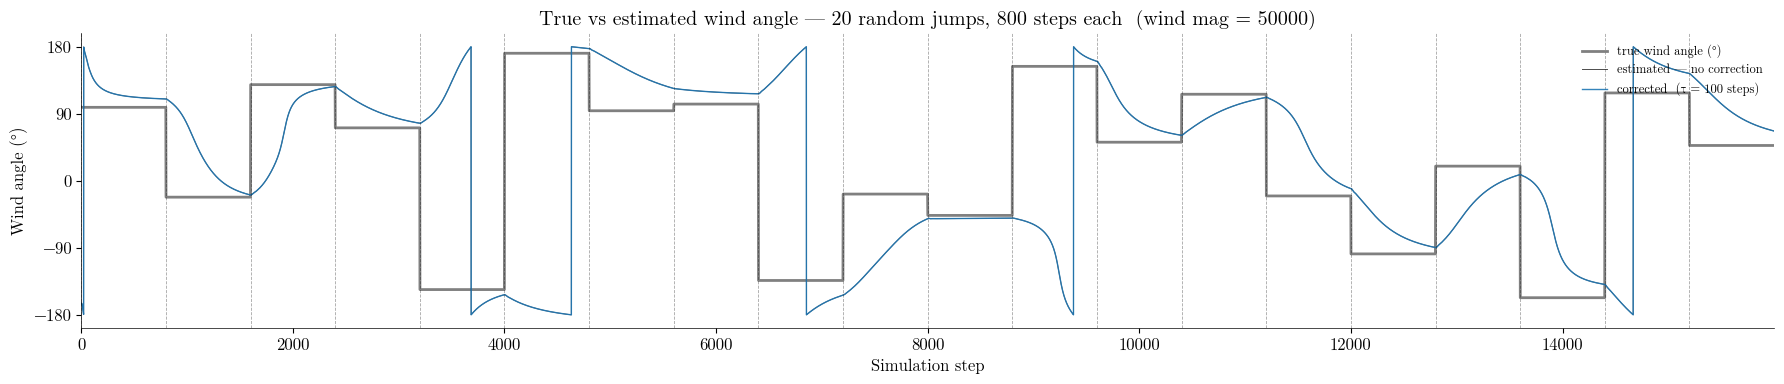

In [147]:
# ── Plot: true vs estimated (raw and corrected) wind angle ────────────────────
fig, ax = plt.subplots(figsize=(18, 4), dpi=100)

ax.plot(tau_ts_step, tau_ts_true,      color="gray", lw=2.0, label="true wind angle (°)")
ax.plot(tau_ts_step, tau_ts_est,       color="C0",   lw=0.7, alpha=0.7,
        label="estimated — no correction")
ax.plot(tau_ts_step, tau_ts_corrected, color="C1",   lw=1.0, alpha=0.9,
        label=f"corrected  (τ = {TAU_CORRECTION} steps)")

for js in tau_jump_steps:
    ax.axvline(js, color="k", lw=0.6, ls="--", alpha=0.35)

ax.set_xlabel("Simulation step")
ax.set_ylabel("Wind angle (°)")
ax.set_yticks([-180, -90, 0, 90, 180])
ax.set_xlim(tau_ts_step[0], tau_ts_step[-1])
ax.legend(fontsize=9, loc="upper right")
ax.set_title(
    f"True vs estimated wind angle — {TAU_N_JUMPS} random jumps, "
    f"{TAU_SETTLE_STEPS} steps each  (wind mag = {TAU_WIND_MAG})"
)
plt.tight_layout()
plt.show()

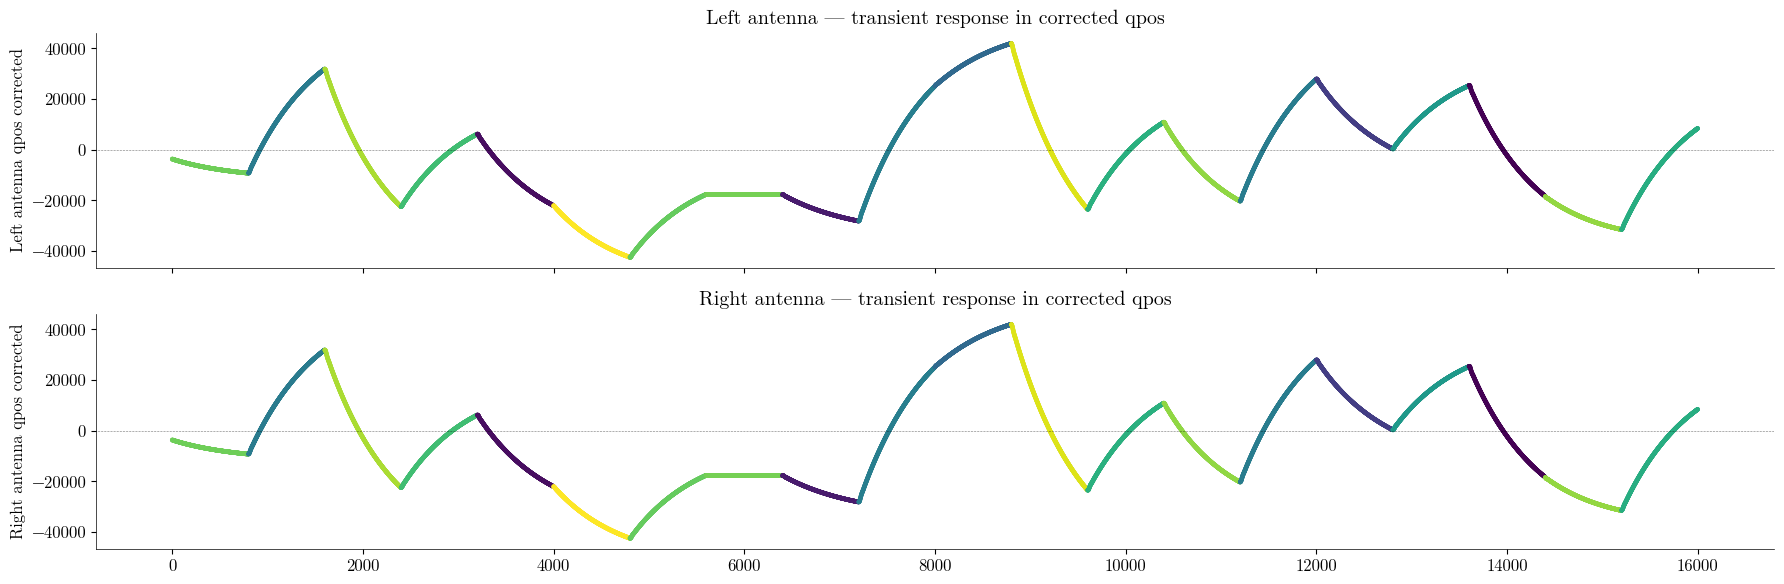

In [150]:
# ── Plot: qpos trajectories ────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 6), dpi=100, sharex=True)
for ax, (xk, yk, title) in zip(
    axes,
    [("l_qx_corr", "l_qy_corr", "Left antenna"),
     ("r_qx_corr", "r_qy_corr", "Right antenna")],
):
    sc = ax.scatter(tau_ts_step, tau_ts_qcorr[:, 0 if xk.endswith("qx") else 1],
                    c=tau_ts_true, cmap="viridis", s=5, alpha=0.7, rasterized=True)
    #plt.colorbar(sc, ax=ax, label="true wind angle (°)")
    ax.axhline(0, color="k", lw=0.4, ls=":")
    ax.set_ylabel(f"{title} qpos corrected")
    ax.set_title(f"{title} — transient response in corrected qpos") 

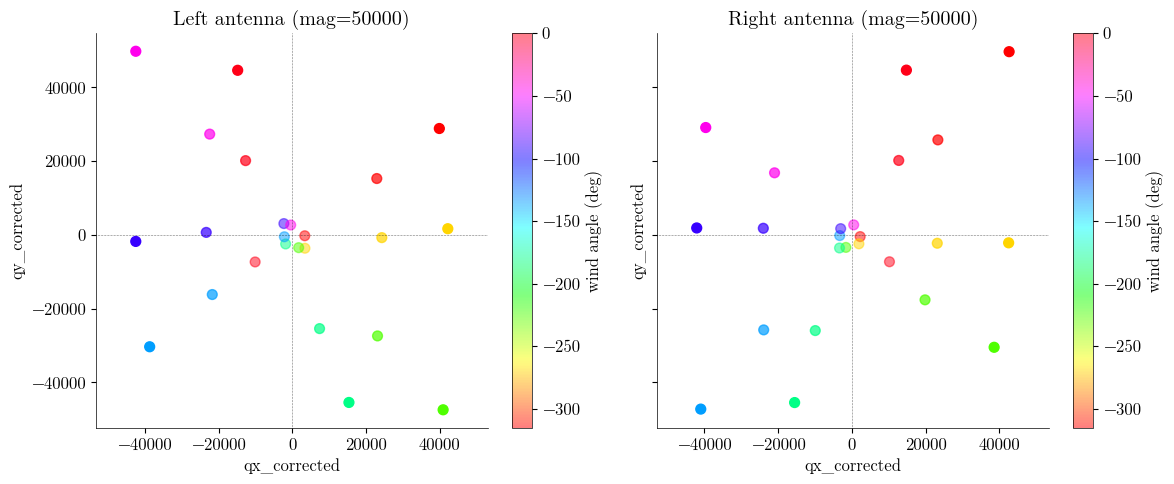

In [130]:
last_step = df['step'].unique().max()
mid_step = df['step'].unique()[len(df['step'].unique()) // 4]

last_qpos = df[(df['step'] == last_step) & (df["magnitude"] == WIND_MAG)].sort_values("angle")
mid_qpos = df[(df['step'] == mid_step)  & (df["magnitude"] == WIND_MAG)].sort_values("angle")
first_qpos = df[(df['step'] == 0) & (df["magnitude"] == WIND_MAG)].sort_values("angle")

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=100, sharey=True)
for ax, (xk, yk), title in zip(
    axes,
    [("l_qx_corr", "l_qy_corr"), ("r_qx_corr", "r_qy_corr")],
    ["Left antenna", "Right antenna"],
):
    sc = ax.scatter(last_qpos[xk], last_qpos[yk], c=last_qpos["angle"], cmap="hsv", alpha=1, s=50, label="last step")
    sc = ax.scatter(mid_qpos[xk], mid_qpos[yk], c=mid_qpos["angle"], cmap="hsv", alpha=0.7, s=50, label="middle step")
    sc = ax.scatter(first_qpos[xk], first_qpos[yk], c=first_qpos["angle"], cmap="hsv", alpha=0.5, s=50, label="first step")
    plt.colorbar(sc, ax=ax, label="wind angle (deg)")
    ax.axhline(0, color="k", lw=0.4, ls=":")
    ax.axvline(0, color="k", lw=0.4, ls=":")
    ax.set_xlabel("qx_corrected")
    ax.set_ylabel("qy_corrected")
    ax.set_aspect("equal", "datalim")
    ax.set_title(f"{title} (mag={WIND_MAG})")

plt.show()

---
## Debugging: Hypothesis 2 — Fly Orientation Sensitivity

The fit was calibrated with the fly on flat ground. If the fly tilts (pitch / roll) during locomotion, the antenna joint frame rotates relative to the world and the apparent wind direction in the antenna frame changes — potentially biasing the estimate.

We test this by placing the fly on ramps of different slopes and measuring the steady-state estimation error. The ramp is added as a tilted box geom to `world.mjcf_root.worldbody` before `Simulation()` is called, so gravity keeps the fly stable without any freezing.

In [104]:
# Step 3: compute df_ramp from raw steady-state data + fit_results
# Requires: df_ramp_raw (from experiment cell) and fit_results (from surface-fit cell above)

df_ramp = df_ramp_raw.copy()
for key in ["l_qx", "l_qy", "r_qx", "r_qy"]:
    p = fit_results[key]
    df_ramp[f"{key}_corr"] = (df_ramp[f"{key}_ss"] - p["bias"]) / p["A"]

l_rad = np.arctan2(df_ramp["l_qx_corr"], df_ramp["l_qy_corr"])
r_rad = np.arctan2(df_ramp["r_qx_corr"], df_ramp["r_qy_corr"])
df_ramp["est"]   = np.degrees(np.angle(np.exp(1j * l_rad) + np.exp(1j * r_rad)))
df_ramp["error"] = wrap_angle(df_ramp["est"] - df_ramp["wind_ang"])

print(f"df_ramp ready: {len(df_ramp)} rows")

df_ramp ready: 160 rows


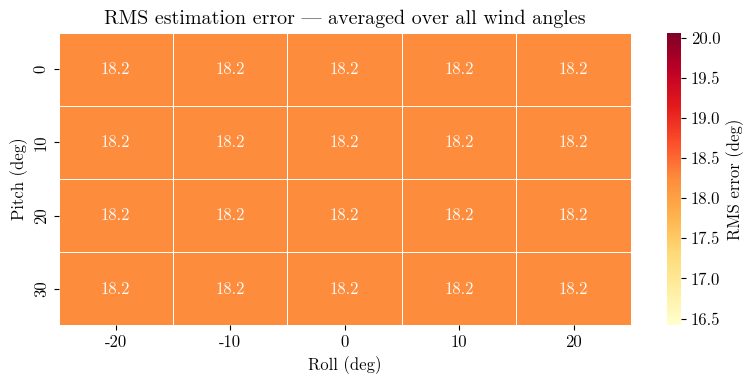

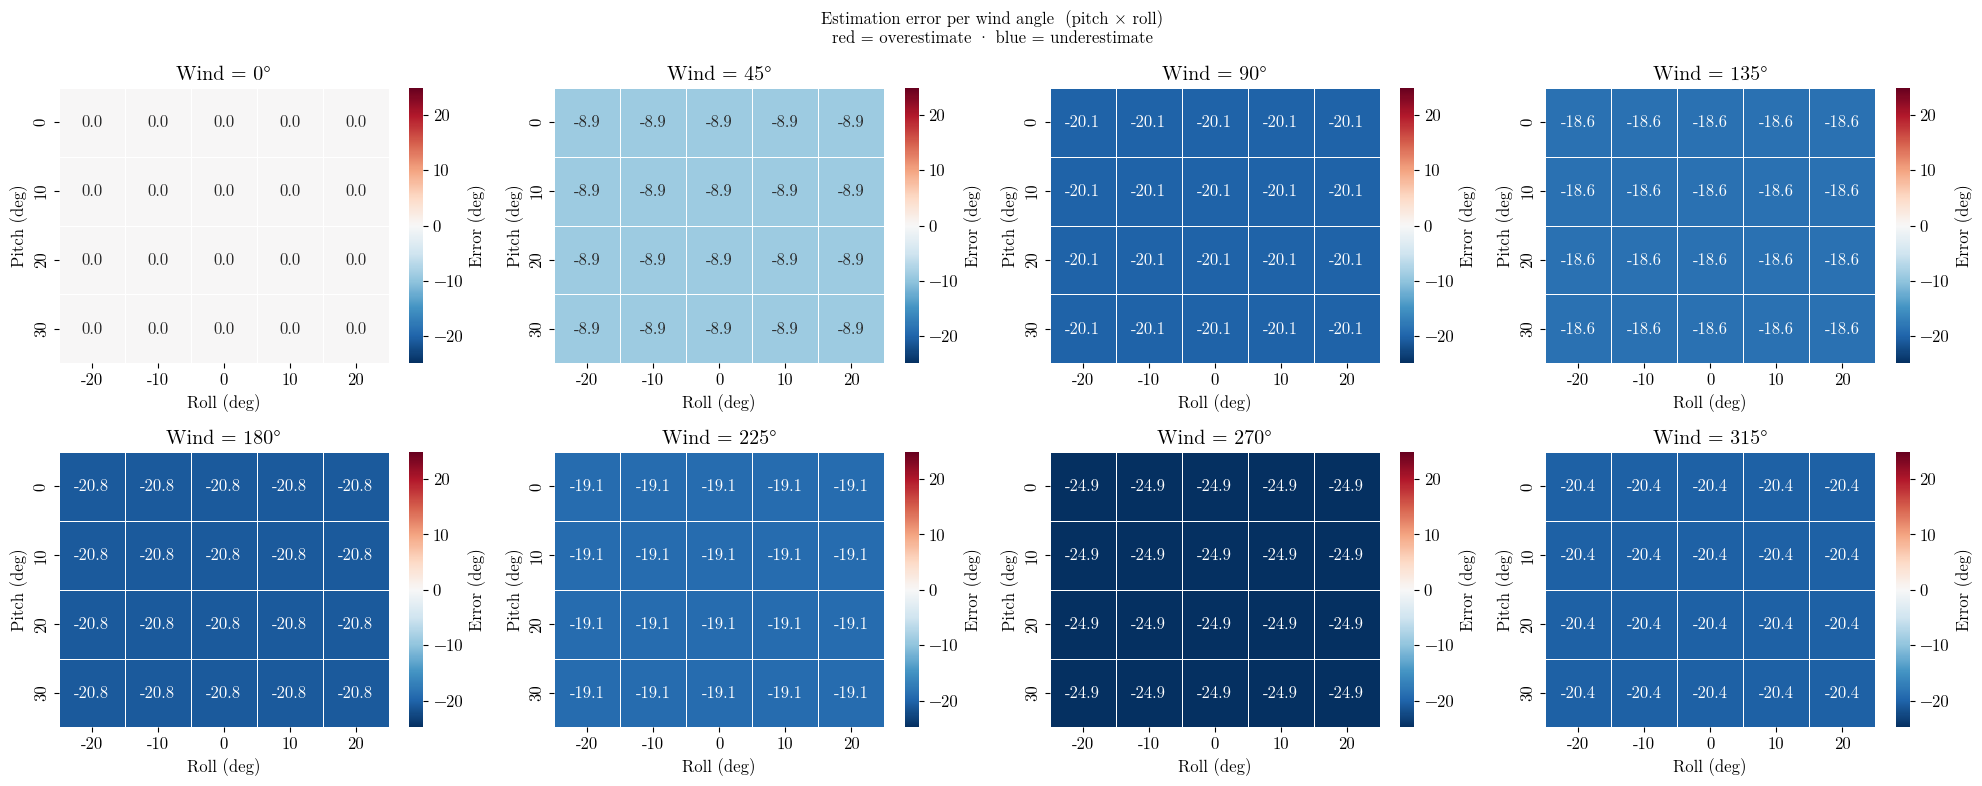


Condition                       RMS error
------------------------------------------
  pitch=  0°, roll=  +0°         18.2°
  pitch=  0°, roll= +10°         18.2°
  pitch=  0°, roll= +20°         18.2°
  pitch=  0°, roll= -10°         18.2°
  pitch=  0°, roll= -20°         18.2°
  pitch= 10°, roll=  +0°         18.2°
  pitch= 10°, roll= +10°         18.2°
  pitch= 10°, roll= +20°         18.2°
  pitch= 10°, roll= -10°         18.2°
  pitch= 10°, roll= -20°         18.2°
  pitch= 20°, roll=  +0°         18.2°
  pitch= 20°, roll= +10°         18.2°
  pitch= 20°, roll= +20°         18.2°
  pitch= 20°, roll= -10°         18.2°
  pitch= 20°, roll= -20°         18.2°
  pitch= 30°, roll=  +0°         18.2°
  pitch= 30°, roll= +10°         18.2°
  pitch= 30°, roll= +20°         18.2°
  pitch= 30°, roll= -10°         18.2°
  pitch= 30°, roll= -20°         18.2°


In [105]:
# Step 3 (plotting): estimation error across all pitch × roll combinations

import seaborn as sns

pitch_vals = sorted(df_ramp["pitch_deg"].unique())
roll_vals  = sorted(df_ramp["roll_deg"].unique())
wind_vals  = sorted(df_ramp["wind_ang"].unique())

# ── Summary heatmap: RMS error averaged over all wind angles ──────────
rms_grid = (
    df_ramp.groupby(["pitch_deg", "roll_deg"])["error"]
    .apply(lambda e: np.sqrt((e**2).mean()))
    .unstack("roll_deg")
    .reindex(index=pitch_vals, columns=sorted(roll_vals))
)

fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
sns.heatmap(rms_grid, annot=True, fmt=".1f", cmap="YlOrRd",
            ax=ax, linewidths=0.5, cbar_kws={"label": "RMS error (deg)"})
ax.set_xlabel("Roll (deg)")
ax.set_ylabel("Pitch (deg)")
ax.set_title("RMS estimation error — averaged over all wind angles")
plt.tight_layout()
plt.show()

# ── Per-wind-angle heatmaps: one panel per wind direction ─────────────
n_wind = len(wind_vals)
ncols  = 4
nrows  = int(np.ceil(n_wind / ncols))

vlim = df_ramp["error"].abs().max()

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), dpi=100)
axes_flat = np.array(axes).flatten()

for ax, wind_ang in zip(axes_flat, wind_vals):
    sub  = df_ramp[df_ramp["wind_ang"] == wind_ang]
    grid = (
        sub.groupby(["pitch_deg", "roll_deg"])["error"]
        .mean()
        .unstack("roll_deg")
        .reindex(index=pitch_vals, columns=sorted(roll_vals))
    )
    sns.heatmap(grid, annot=True, fmt=".1f", cmap="RdBu_r",
                vmin=-vlim, vmax=vlim, ax=ax, linewidths=0.5,
                cbar_kws={"label": "Error (deg)"})
    ax.set_title(f"Wind = {wind_ang}°")
    ax.set_xlabel("Roll (deg)")
    ax.set_ylabel("Pitch (deg)")

for ax in axes_flat[n_wind:]:
    ax.set_visible(False)

plt.suptitle(
    "Estimation error per wind angle  (pitch × roll)\n"
    "red = overestimate · blue = underestimate",
    fontsize=12,
)
plt.tight_layout()
plt.show()

print(f"\n{'Condition':<28} {'RMS error':>12}")
print("-" * 42)
for pitch in RAMP_PITCH_ANGLES:
    for roll in RAMP_ROLL_ANGLES:
        g = df_ramp[(df_ramp["pitch_deg"] == pitch) & (df_ramp["roll_deg"] == roll)]
        print(f"  pitch={pitch:>3}°, roll={roll:>+4}°   {np.sqrt((g['error']**2).mean()):>10.1f}°")

In [ ]:
# Step 3b: scatter — error for a single wind angle across all pitch × roll combinations

import ipywidgets as widgets
from IPython.display import display

def plot_wind_scatter(wind_ang):
    sub = df_ramp[df_ramp["wind_ang"] == wind_ang].copy()

    fig, ax = plt.subplots(figsize=(7, 5), dpi=100)
    sc = ax.scatter(
        sub["roll_deg"], sub["pitch_deg"],
        c=sub["error"], cmap="RdBu_r",
        vmin=-vlim, vmax=vlim,
        s=300, edgecolors="k", linewidths=0.6,
    )
    for _, row in sub.iterrows():
        ax.annotate(f"{row['error']:.5f}°",
                    (row["roll_deg"], row["pitch_deg"]),
                    ha="center", va="center", fontsize=8, fontweight="bold")

    plt.colorbar(sc, ax=ax, label="Error (deg)")
    ax.set_xlabel("Roll (deg)")
    ax.set_ylabel("Pitch (deg)")
    ax.set_title(f"Estimation error  —  wind = {wind_ang}°\n(red = overestimate · blue = underestimate)")
    ax.set_xticks(sorted(df_ramp["roll_deg"].unique()))
    ax.set_yticks(sorted(df_ramp["pitch_deg"].unique()))
    ax.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

wind_selector = widgets.Dropdown(
    options=wind_vals,
    value=wind_vals[0],
    description="Wind angle:",
)
widgets.interact(plot_wind_scatter, wind_ang=wind_selector)


interactive(children=(Dropdown(description='Wind angle:', options=(np.int64(0), np.int64(45), np.int64(90), np…

<function __main__.plot_wind_scatter(wind_ang)>

---
## Debugging: Hypothesis 3 — Locomotion-Induced Antenna Jitter

The previous checks used a stationary fly. Here the fly walks straight with the same wind directions used above, while we record raw antenna `qpos x` and `qpos y`. If the walking dynamics are contaminating the wind signal, these traces should show step-synchronous jitter beyond the wind-driven mean deflection.


In [72]:
# Hypothesis 3: straight walking under wind, then inspect qpos x/y jitter
from flygym.examples.locomotion.cpg_network import CPGNetwork
from flygym.examples.locomotion.preprogrammed_steps import PreprogrammedSteps

HYP3_WIND_MAG = WIND_MAG if "WIND_MAG" in globals() else 50000
HYP3_WIND_ANGLES = TEST_ANGLES if "TEST_ANGLES" in globals() else [0, -45, -90, -135, -180, -225, -270, -315]
HYP3_WARMUP_STEPS = 500       # straight walking before wind onset
HYP3_WIND_STEPS = 2500        # recorded straight walking with wind on
HYP3_JITTER_SKIP = 500        # skip antenna transient when summarising jitter

_tripod_phase_biases = np.pi * np.array(
    [
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
        [0, 1, 0, 1, 0, 1],
        [1, 0, 1, 0, 1, 0],
    ]
)
_tripod_coupling_weights = (_tripod_phase_biases > 0) * 10


def make_straight_walk_controller(timestep, seed=0):
    preprogrammed_steps = PreprogrammedSteps()
    cpg = CPGNetwork(
        timestep=timestep,
        intrinsic_freqs=np.ones(6) * 12,
        intrinsic_amps=np.ones(6),
        coupling_weights=_tripod_coupling_weights,
        phase_biases=_tripod_phase_biases,
        convergence_coefs=np.ones(6) * 20,
        seed=seed,
    )
    return preprogrammed_steps, cpg


def straight_walk_action(preprogrammed_steps, cpg):
    cpg.step()
    joint_angles = []
    adhesion_onoff = []
    for leg_i, leg in enumerate(preprogrammed_steps.legs):
        joint_angles.append(
            preprogrammed_steps.get_joint_angles(
                leg, cpg.curr_phases[leg_i], cpg.curr_magnitudes[leg_i]
            )
        )
        adhesion_onoff.append(
            preprogrammed_steps.get_adhesion_onoff(leg, cpg.curr_phases[leg_i])
        )
    return np.concatenate(joint_angles), np.asarray(adhesion_onoff)


hyp3_records = []

for angle_deg in HYP3_WIND_ANGLES:
    fly_h3 = create_fly()
    world_h3 = FlatGroundWorld()
    checker_h3 = world_h3.mjcf_root.find("texture", "checker")
    if checker_h3 is not None:
        checker_h3.rgb1 = (1, 1, 1)
        checker_h3.rgb2 = (1, 1, 1)
    world_h3.add_fly(
        fly_h3,
        spawn_position=(0, 0, 0.1),
        spawn_rotation=Rotation3D("quat", (0, 0, 0, 1)),
    )

    sim_h3 = Simulation(world_h3)
    sim_h3.reset()
    preprogrammed_steps, cpg = make_straight_walk_controller(sim_h3.timestep, seed=0)

    # Let the gait settle before wind onset so the recorded segment isolates wind-on walking.
    for _ in range(HYP3_WARMUP_STEPS):
        joint_angles, adhesion = straight_walk_action(preprogrammed_steps, cpg)
        sim_h3.set_actuator_inputs(fly_h3.name, ActuatorType.POSITION, joint_angles)
        sim_h3.set_actuator_inputs(fly_h3.name, ActuatorType.ADHESION, adhesion)
        sim_h3.step()

    sim_h3.set_wind(HYP3_WIND_MAG, angle_deg)
    for step in range(HYP3_WIND_STEPS):
        joint_angles, adhesion = straight_walk_action(preprogrammed_steps, cpg)
        sim_h3.set_actuator_inputs(fly_h3.name, ActuatorType.POSITION, joint_angles)
        sim_h3.set_actuator_inputs(fly_h3.name, ActuatorType.ADHESION, adhesion)
        sim_h3.step()

        ant = sim_h3.get_antenna_data(fly_h3.name)
        hyp3_records.append(
            {
                "angle": angle_deg,
                "step": step,
                "l_qx": ant["l"]["qpos"][1],
                "l_qy": ant["l"]["qpos"][2],
                "r_qx": ant["r"]["qpos"][1],
                "r_qy": ant["r"]["qpos"][2],
            }
        )

    sim_h3.set_wind(0, 0)

df_hyp3 = pd.DataFrame(hyp3_records)
print(f"Hypothesis 3 data: {len(df_hyp3)} rows, {df_hyp3['angle'].nunique()} wind angles")


Hypothesis 3 data: 20000 rows, 8 wind angles


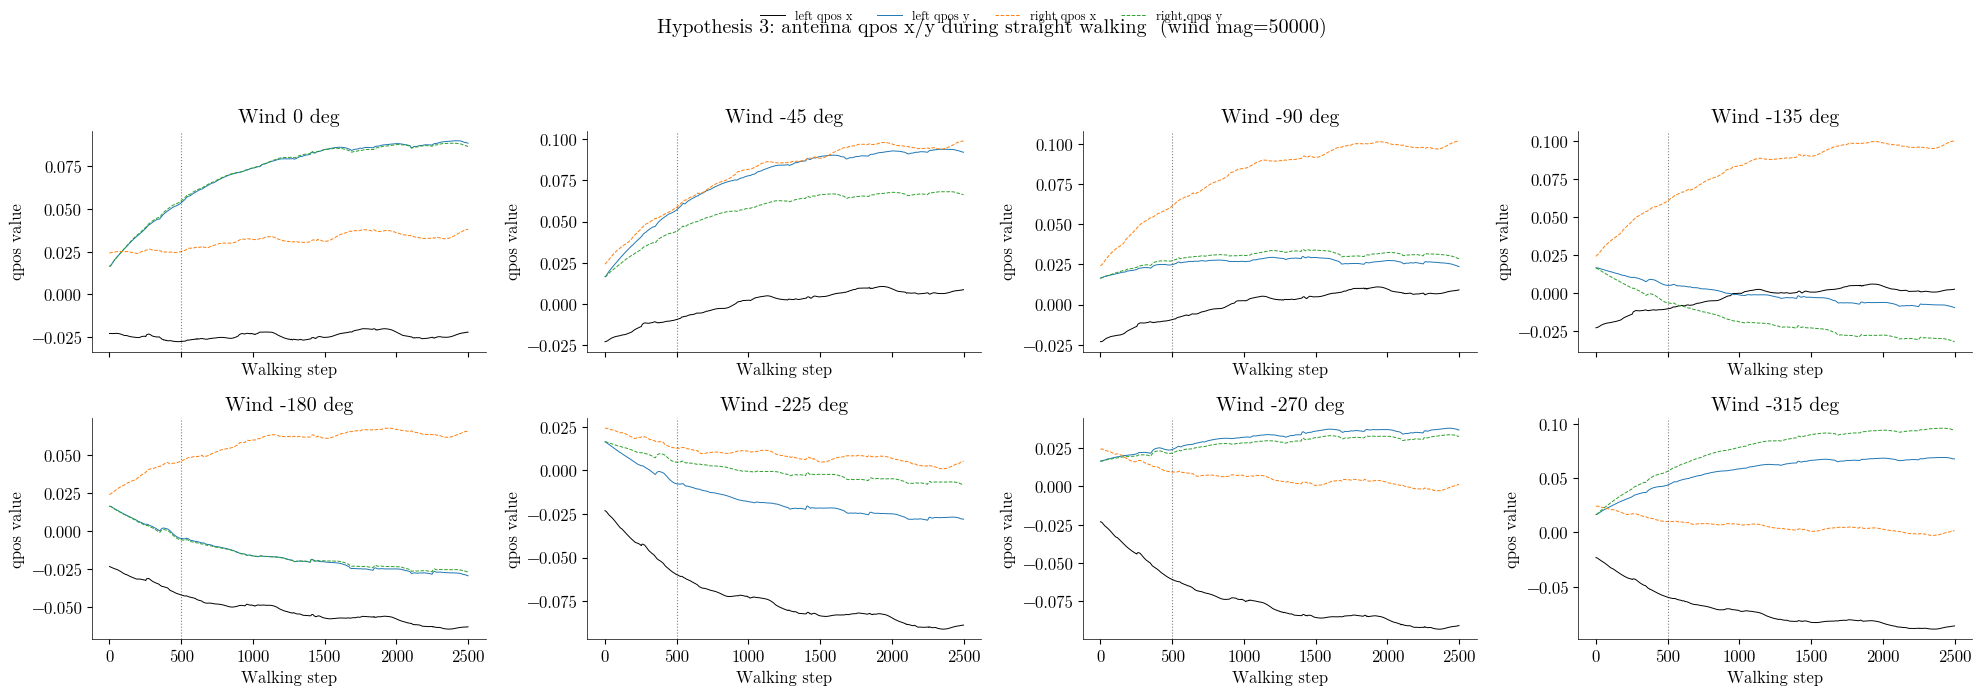

,angle,l_qx_std,l_qx_diff_std,l_qy_std,l_qy_diff_std,r_qx_std,r_qx_diff_std,r_qy_std,r_qy_diff_std
0,-315,0.007936,0.000035,0.006466,0.000031,0.003435,0.000032,0.010396,0.000034
1,-270,0.008603,0.000036,0.003272,0.000032,0.003301,0.000034,0.002772,0.000033
2,-225,0.008209,0.000033,0.005671,0.000033,0.003120,0.000034,0.003611,0.000033
3,-180,0.005958,0.000032,0.006724,0.000035,0.005531,0.000035,0.005813,0.000037
4,-135,0.003967,0.000034,0.004145,0.000031,0.010542,0.000036,0.006948,0.000034
5,-90,0.005159,0.000036,0.001325,0.000029,0.010763,0.000036,0.001445,0.000032
6,-45,0.004988,0.000034,0.009690,0.000032,0.010495,0.000035,0.006154,0.000032
7,0,0.002017,0.000035,0.009442,0.000031,0.003108,0.000033,0.008885,0.000032


In [73]:
# Plot walking data
# One panel per wind direction: raw antenna qpos x/y while the fly walks straight.
ncols = 4
nrows = int(np.ceil(len(HYP3_WIND_ANGLES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 7), dpi=100, sharex=True)
axes = np.asarray(axes).ravel()

for ax, angle_deg in zip(axes, HYP3_WIND_ANGLES):
    g = df_hyp3[df_hyp3["angle"] == angle_deg]
    ax.plot(g["step"], g["l_qx"], lw=0.7, label="left qpos x")
    ax.plot(g["step"], g["l_qy"], lw=0.7, label="left qpos y")
    ax.plot(g["step"], g["r_qx"], lw=0.7, ls="--", label="right qpos x")
    ax.plot(g["step"], g["r_qy"], lw=0.7, ls="--", label="right qpos y")
    ax.axvline(HYP3_JITTER_SKIP, color="k", lw=0.8, ls=":", alpha=0.5)
    ax.set_title(f"Wind {angle_deg} deg")
    ax.set_xlabel("Walking step")
    ax.set_ylabel("qpos value")

for ax in axes[len(HYP3_WIND_ANGLES):]:
    ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=9)
plt.suptitle(f"Hypothesis 3: antenna qpos x/y during straight walking  (wind mag={HYP3_WIND_MAG})")
plt.tight_layout(rect=(0, 0, 1, 0.93))
plt.show()

# Compact jitter score: raw spread and step-to-step jitter after the wind transient.
jitter_rows = []
for angle_deg, g in df_hyp3[df_hyp3["step"] >= HYP3_JITTER_SKIP].groupby("angle"):
    row = {"angle": angle_deg}
    for key in ["l_qx", "l_qy", "r_qx", "r_qy"]:
        row[f"{key}_std"] = g[key].std()
        row[f"{key}_diff_std"] = g[key].diff().std()
    jitter_rows.append(row)

hyp3_jitter_summary = pd.DataFrame(jitter_rows).sort_values("angle")
display(hyp3_jitter_summary)

In [ ]:
import ipywidgets as widgets
from matplotlib.lines import Line2D

# ── stationary reference: full time-series from the main-sweep df ────────────
# Pull all steps (0-1999) for each wind angle so we get both the settling
# transient and the steady state — the no-locomotion counterpart to df_hyp3.
_stat_ref = {}
for _angle in HYP3_WIND_ANGLES:
    _g = df[df["angle"] == _angle].sort_values("step")
    if len(_g):
        _stat_ref[_angle] = {
            "step": _g["step"].values,
            **{k: _g[k].values for k in ["l_qx", "l_qy", "r_qx", "r_qy"]},
        }

def smooth(y, window):
    """Symmetric moving-average; 'same' keeps the original length."""
    w = max(1, int(window))
    return np.convolve(np.asarray(y, dtype=float), np.ones(w) / w, mode="same")

_colors = {"l_qx": "C0", "l_qy": "C1", "r_qx": "C2", "r_qy": "C3"}
_labels = {"l_qx": "left qpos x", "l_qy": "left qpos y",
           "r_qx": "right qpos x", "r_qy": "right qpos y"}
_ncols = 4
_nrows = int(np.ceil(len(HYP3_WIND_ANGLES) / _ncols))

@widgets.interact(
    win=widgets.IntSlider(min=1, max=500, step=10, value=200,
                          description="Smooth win", continuous_update=False)
)
def plot_h3(win=200):
    fig, axes = plt.subplots(_nrows, _ncols, figsize=(20, 5 * _nrows),
                             dpi=100, sharex=True)
    axes = np.asarray(axes).ravel()

    for ax, angle_deg in zip(axes, HYP3_WIND_ANGLES):
        g     = df_hyp3[df_hyp3["angle"] == angle_deg]
        steps = g["step"].values

        for key in ["l_qx", "l_qy", "r_qx", "r_qy"]:
            vals = g[key].values
            c    = _colors[key]
            # dashed = raw walking signal (shows the jitter)
            ax.plot(steps, vals,              lw=0.5, ls="--", color=c, alpha=0.40)
            # solid  = smoothed walking signal
            ax.plot(steps, smooth(vals, win),  lw=1.5,          color=c)
            # dotted = stationary fly time-series from df (no locomotion noise)
            if angle_deg in _stat_ref:
                s = _stat_ref[angle_deg]
                ax.plot(s["step"], s[key], lw=0.8, ls=":", color=c, alpha=0.75)

        ax.axvline(HYP3_JITTER_SKIP, color="k", lw=0.8, ls=":", alpha=0.4)
        ax.set_title(f"Wind {angle_deg}\u00b0")
        ax.set_xlabel("Walking step")
        ax.set_ylabel("qpos value")

    for ax in axes[len(HYP3_WIND_ANGLES):]:
        ax.axis("off")

    style_handles = [
        Line2D([0], [0], color="k", lw=1.5,                     label="smoothed walking (solid)"),
        Line2D([0], [0], color="k", lw=0.5, ls="--", alpha=0.5, label="raw walking (dashed)"),
        Line2D([0], [0], color="k", lw=0.8, ls=":",  alpha=0.75, label="stationary / no walking (dotted)"),
    ]
    color_handles = [Line2D([0], [0], color=_colors[k], lw=2, label=_labels[k])
                     for k in _colors]
    fig.legend(handles=style_handles + color_handles,
               loc="upper center", ncol=4, fontsize=9)
    plt.suptitle(
        f"H3: qpos x/y \u2014 walking (raw + smoothed) vs stationary  "
        f"(wind mag={HYP3_WIND_MAG}, smooth win={win})",
        fontsize=11,
    )
    plt.tight_layout(rect=(0, 0, 1, 0.91))
    plt.show()

# ── jitter summary table (uses raw walking data, post-transient) ─────────────
jitter_rows = []
for angle_deg, g in df_hyp3[df_hyp3["step"] >= HYP3_JITTER_SKIP].groupby("angle"):
    row = {"angle": angle_deg}
    for key in ["l_qx", "l_qy", "r_qx", "r_qy"]:
        row[f"{key}_std"]      = g[key].std()
        row[f"{key}_diff_std"] = g[key].diff().std()
    jitter_rows.append(row)

hyp3_jitter_summary = pd.DataFrame(jitter_rows).sort_values("angle")
display(hyp3_jitter_summary)

interactive(children=(IntSlider(value=200, continuous_update=False, description='Smooth win', max=500, min=1, …

,angle,l_qx_std,l_qx_diff_std,l_qy_std,l_qy_diff_std,r_qx_std,r_qx_diff_std,r_qy_std,r_qy_diff_std
0,-315,0.007936,0.000035,0.006466,0.000031,0.003435,0.000032,0.010396,0.000034
1,-270,0.008603,0.000036,0.003272,0.000032,0.003301,0.000034,0.002772,0.000033
2,-225,0.008209,0.000033,0.005671,0.000033,0.003120,0.000034,0.003611,0.000033
3,-180,0.005958,0.000032,0.006724,0.000035,0.005531,0.000035,0.005813,0.000037
4,-135,0.003967,0.000034,0.004145,0.000031,0.010542,0.000036,0.006948,0.000034
5,-90,0.005159,0.000036,0.001325,0.000029,0.010763,0.000036,0.001445,0.000032
6,-45,0.004988,0.000034,0.009690,0.000032,0.010495,0.000035,0.006154,0.000032
7,0,0.002017,0.000035,0.009442,0.000031,0.003108,0.000033,0.008885,0.000032
